In [1]:
# Importa moduli di terze parti
import os
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pickle
# Importa moduli toolbox
from toolbox.plots.Plot import CM_plot
from toolbox.functions.Functions import load_npz, extract_window_size, calc_mean_std

In [2]:
dataset_number=1
dataset='dataset '+str(dataset_number)

# If EEGNET or CNN use an empty string for feature_selection
#feature_selection = 'All_Features'
feature_selection = ''
classifiers=['EEGNet']

n_classes=4

#classifiers=['EEGNet','EEGNetK150', 'EEGNetK50']
animals= ['Animal 1', 'Animal 2','Animal 3']
windows = ['500', '200', '100', '50']

#animals= ['Animal 1']
#windows = ['500']



# Confusion Matrix per Animal, window and CV

 ### Replace with the actual path to your base folder
    

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 1/500ms/EEGNet_4_class_Animal 1_500ms_results.pickle


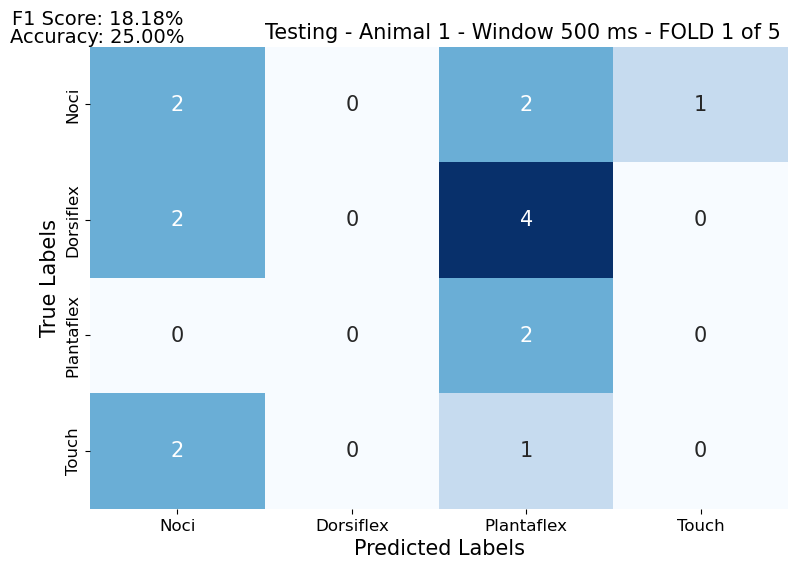

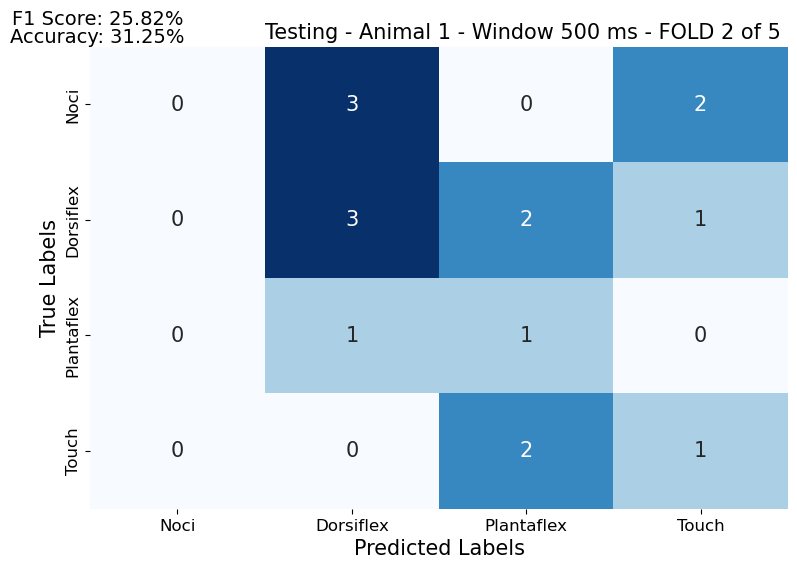

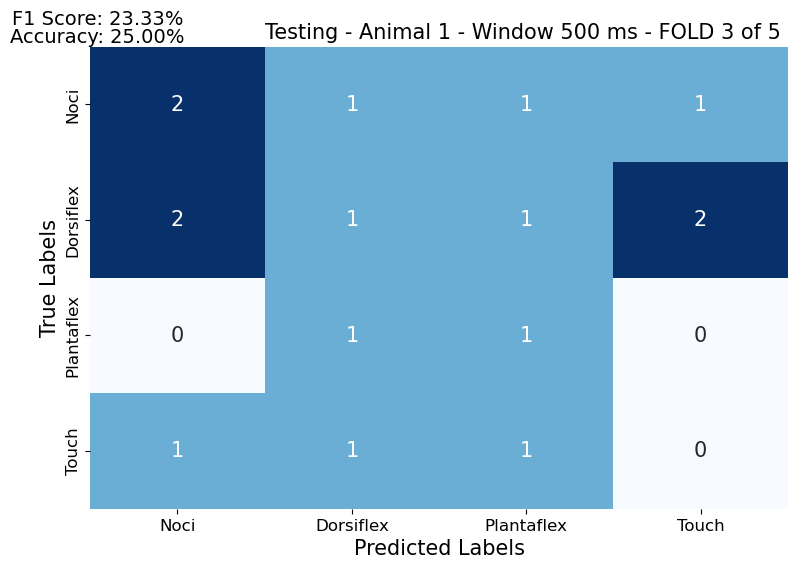

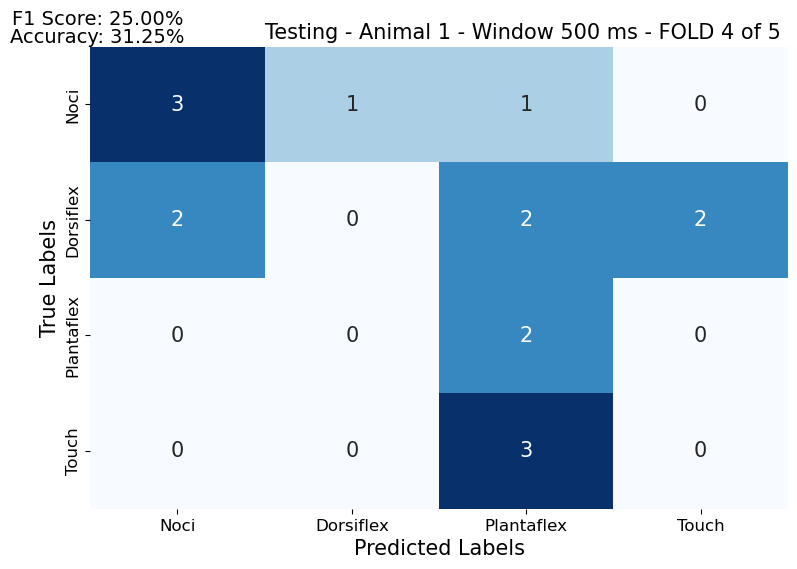

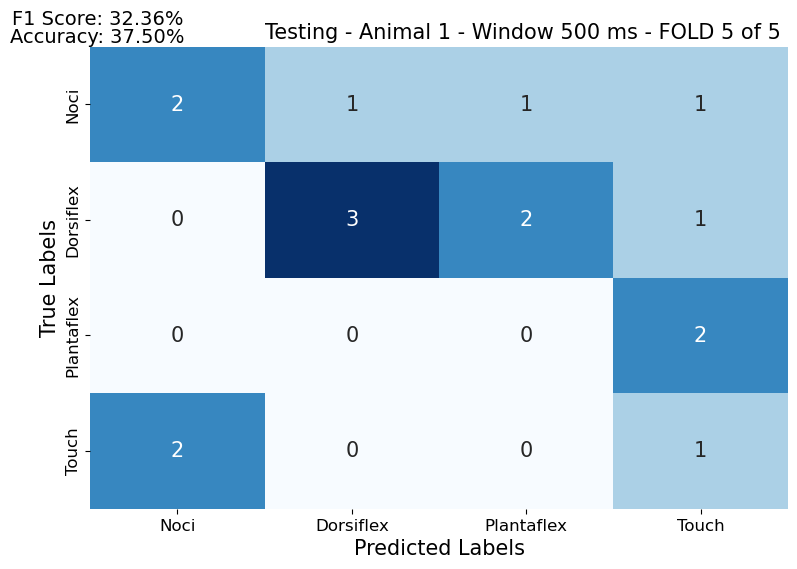

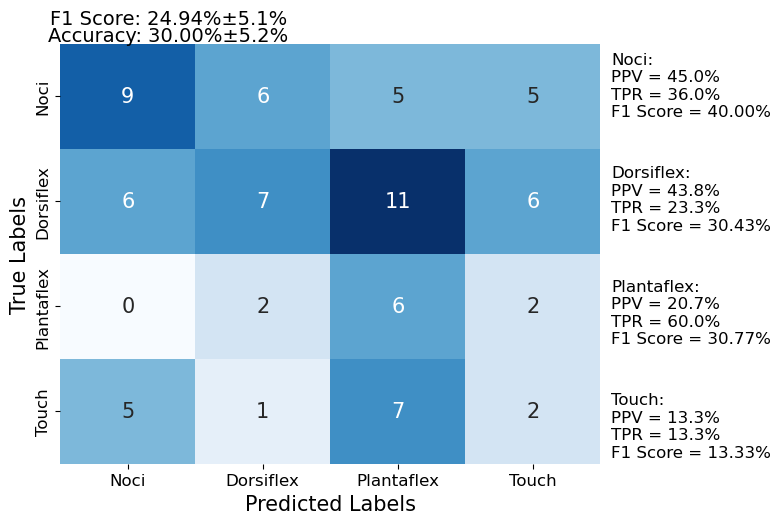

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 1/200ms/EEGNet_4_class_Animal 1_200ms_results.pickle


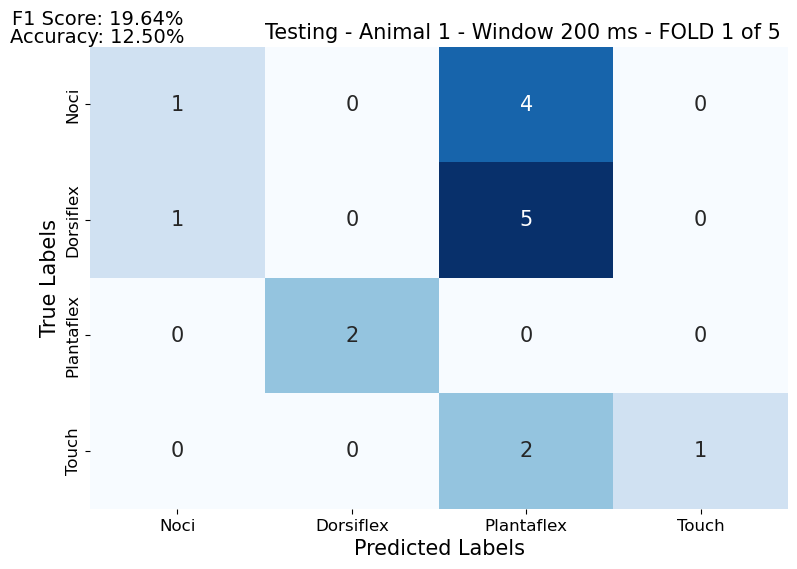

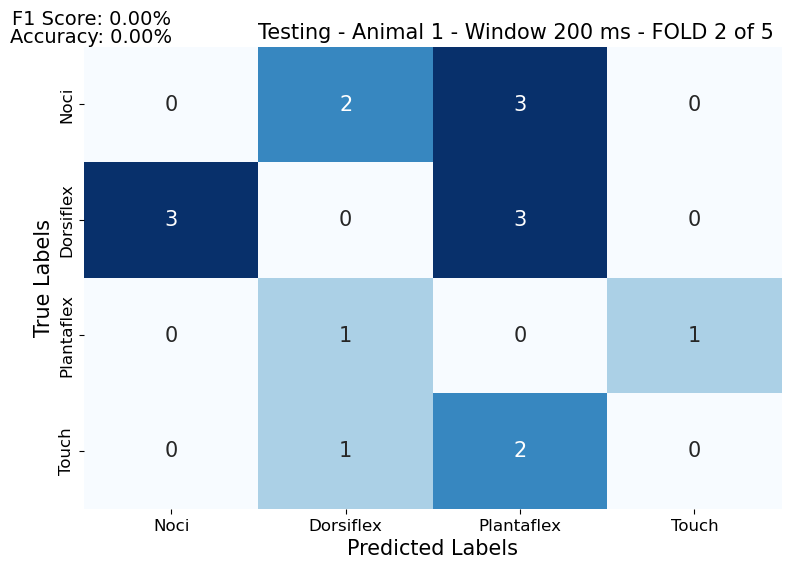

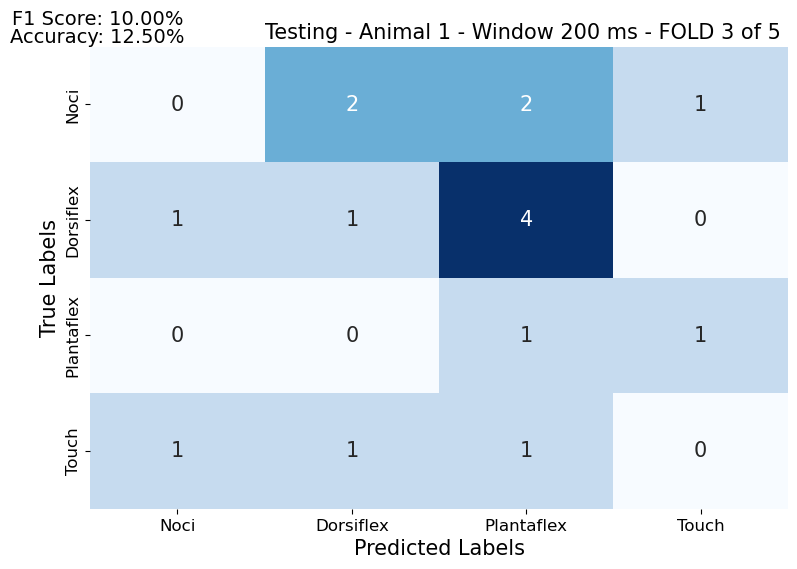

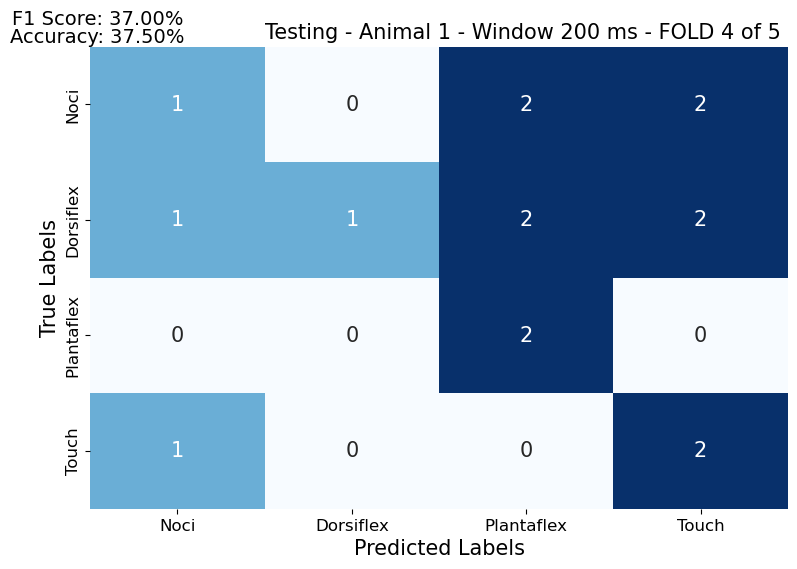

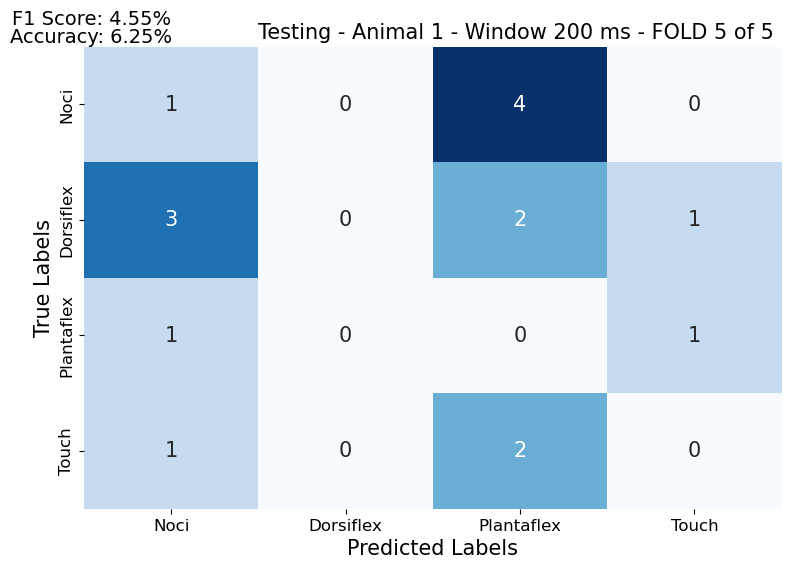

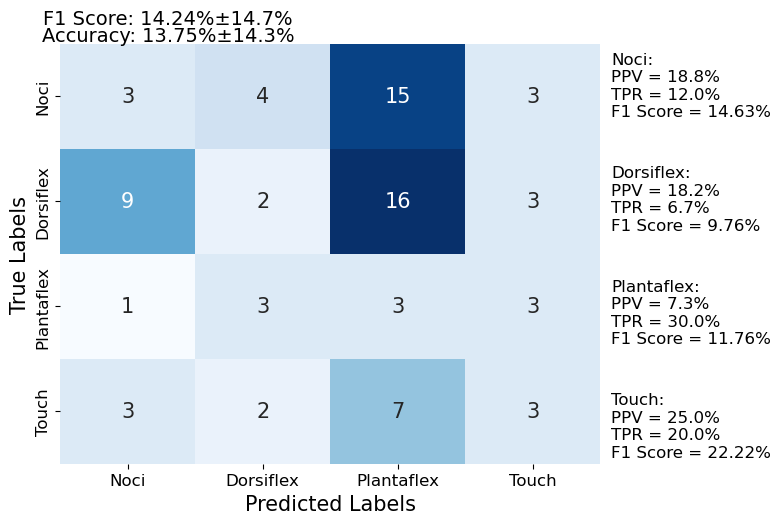

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 1/100ms/EEGNet_4_class_Animal 1_100ms_results.pickle


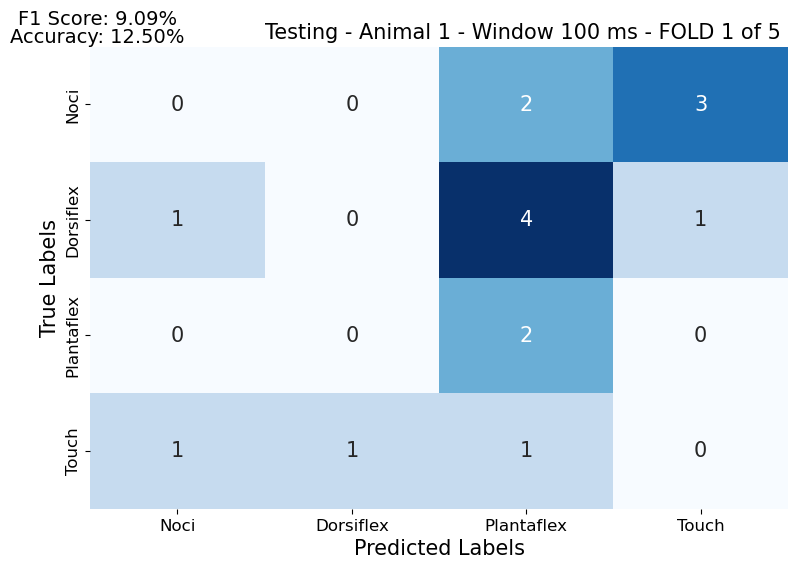

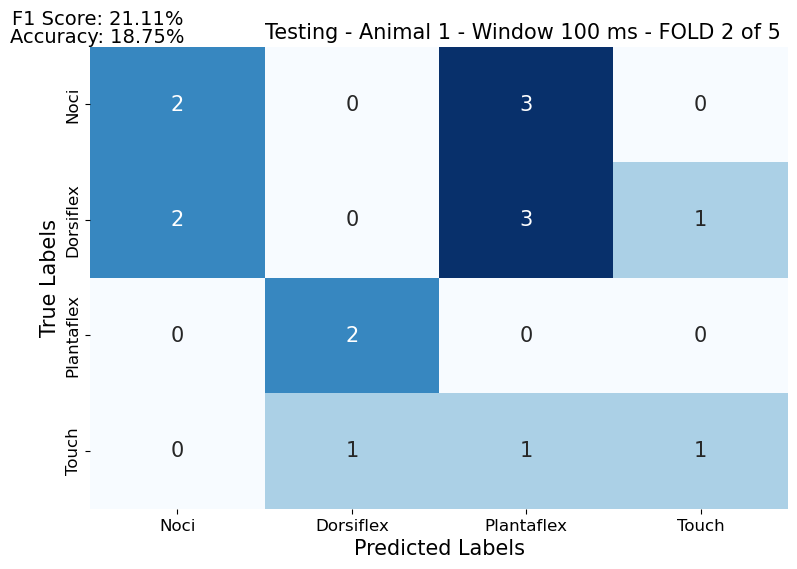

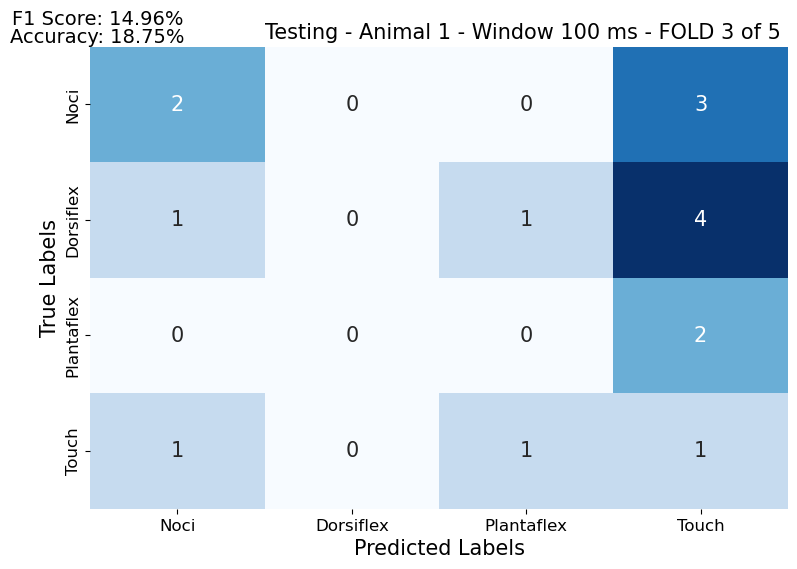

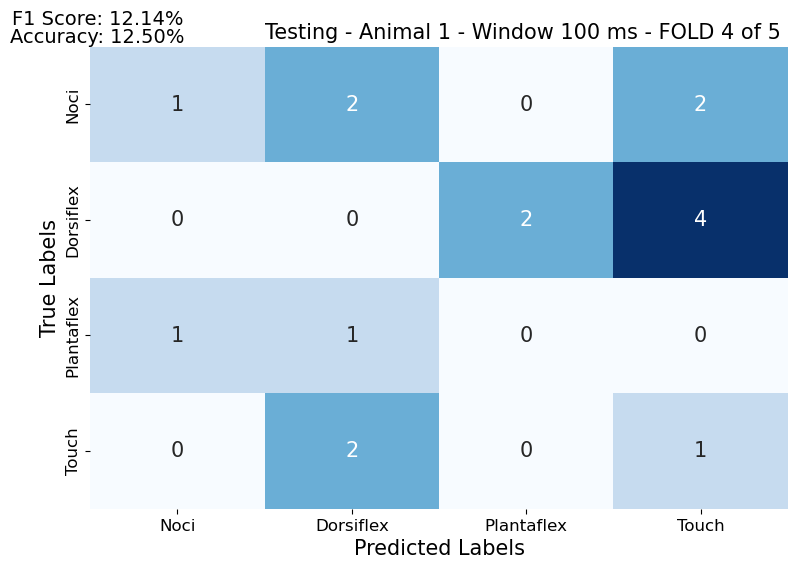

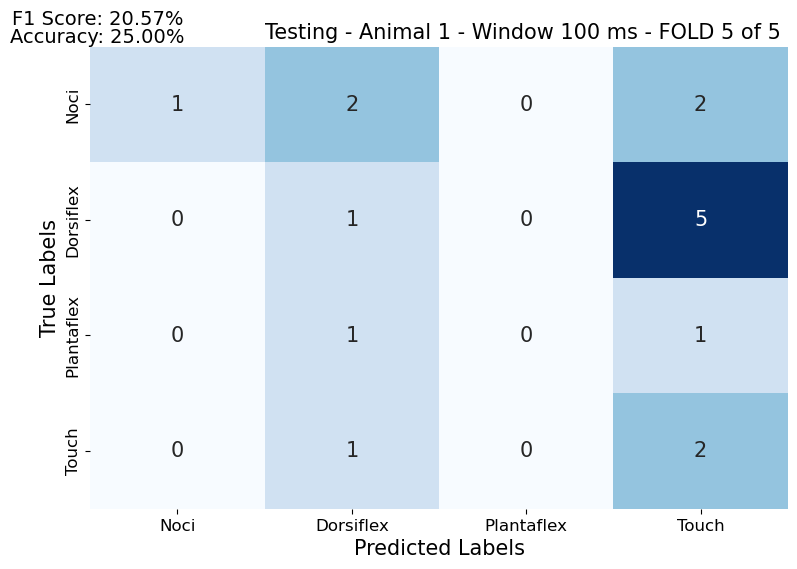

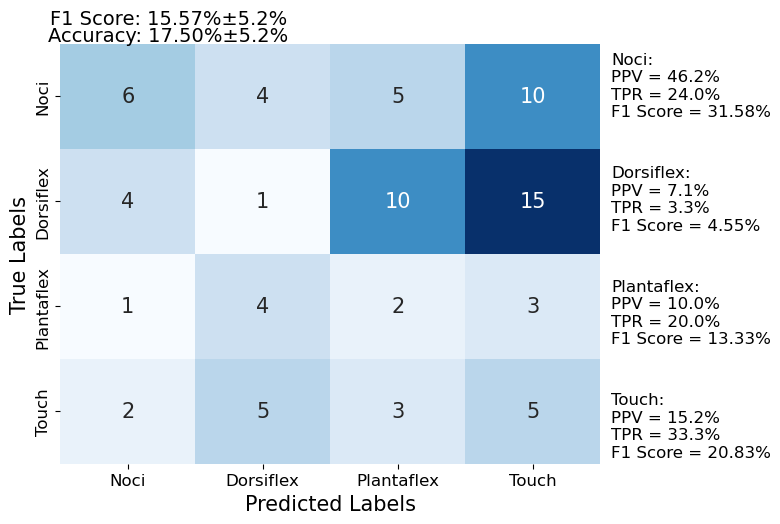

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 1/50ms/EEGNet_4_class_Animal 1_50ms_results.pickle


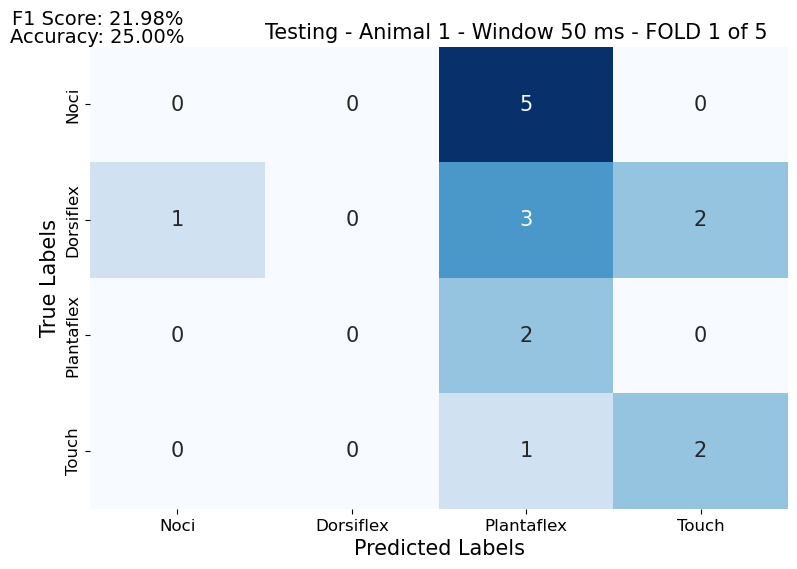

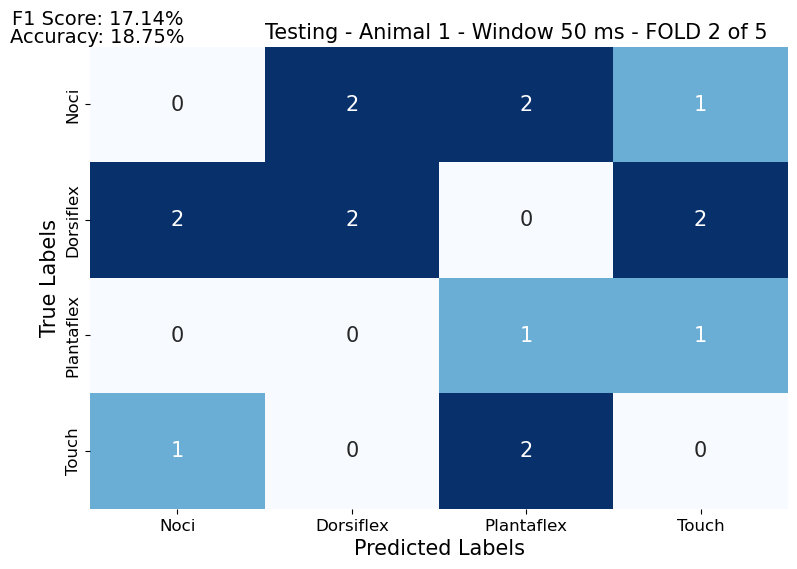

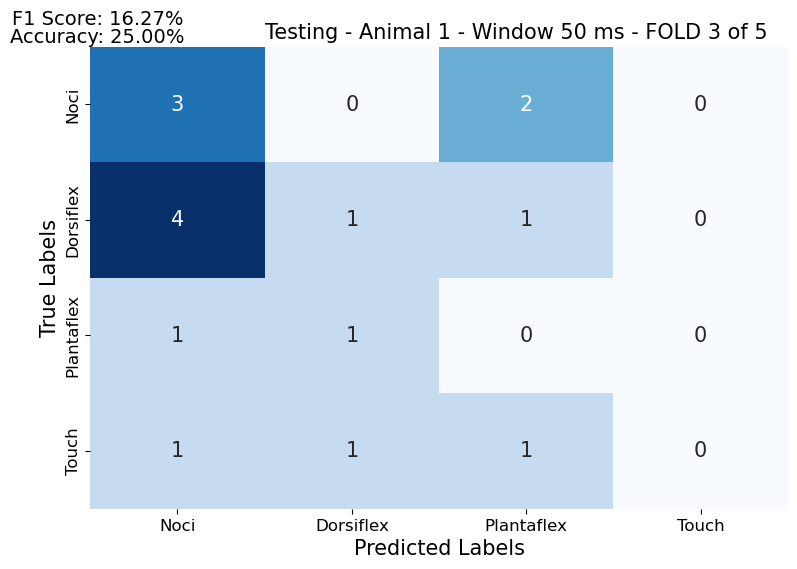

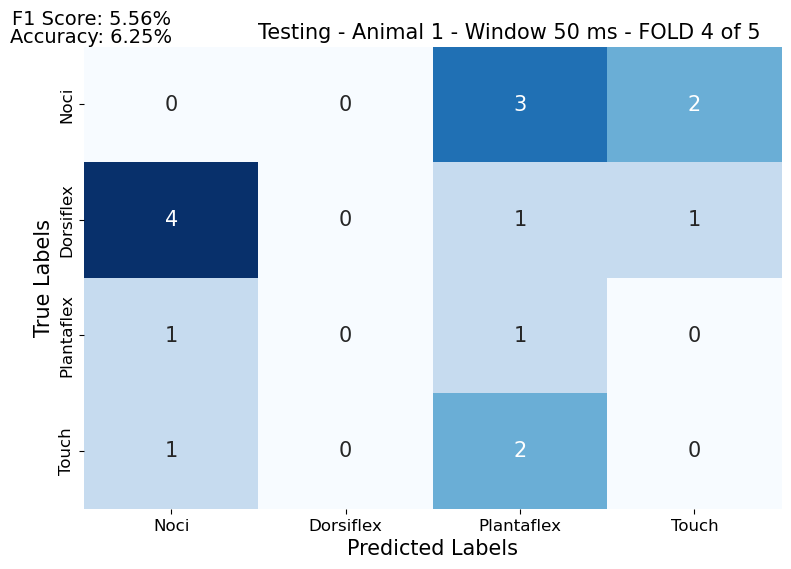

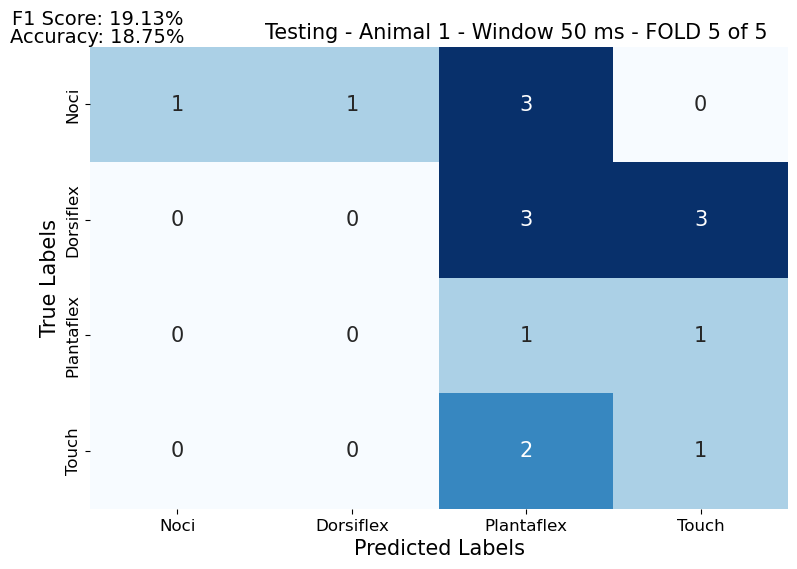

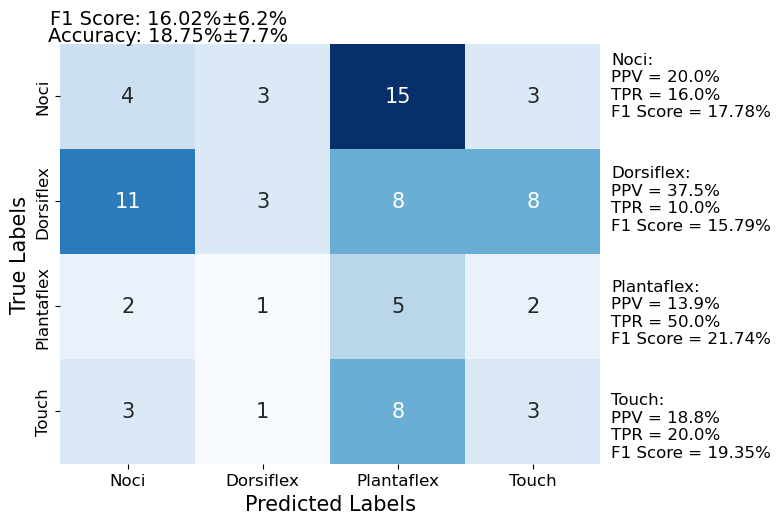

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 2/500ms/EEGNet_4_class_Animal 2_500ms_results.pickle


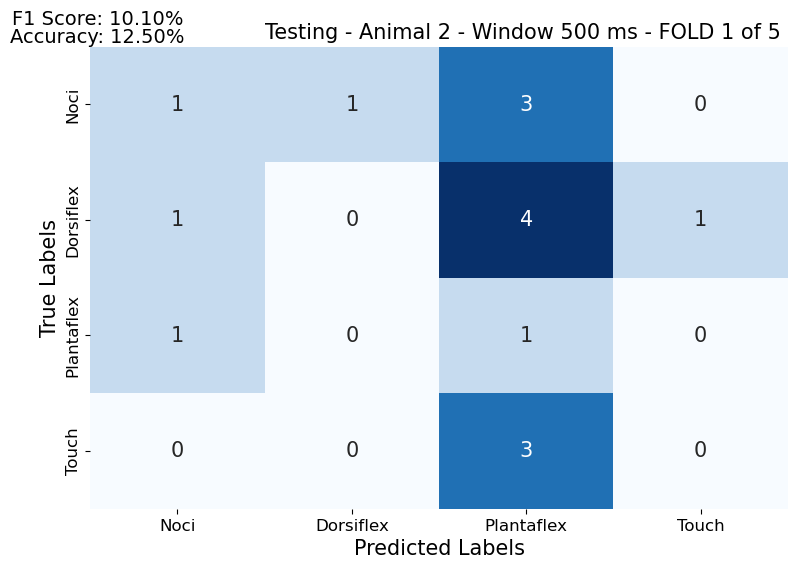

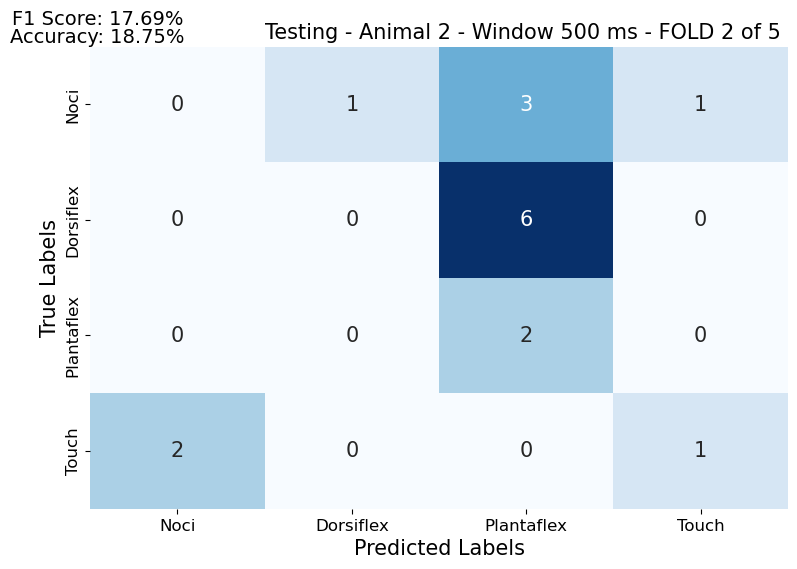

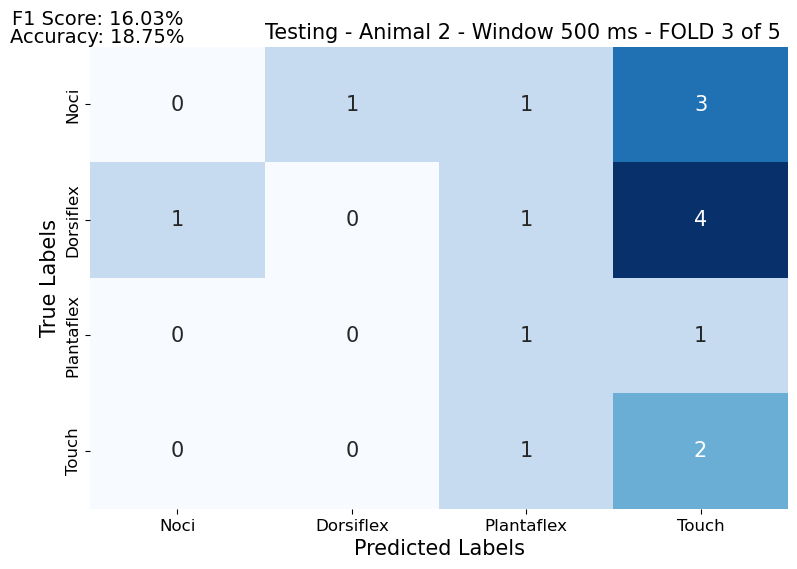

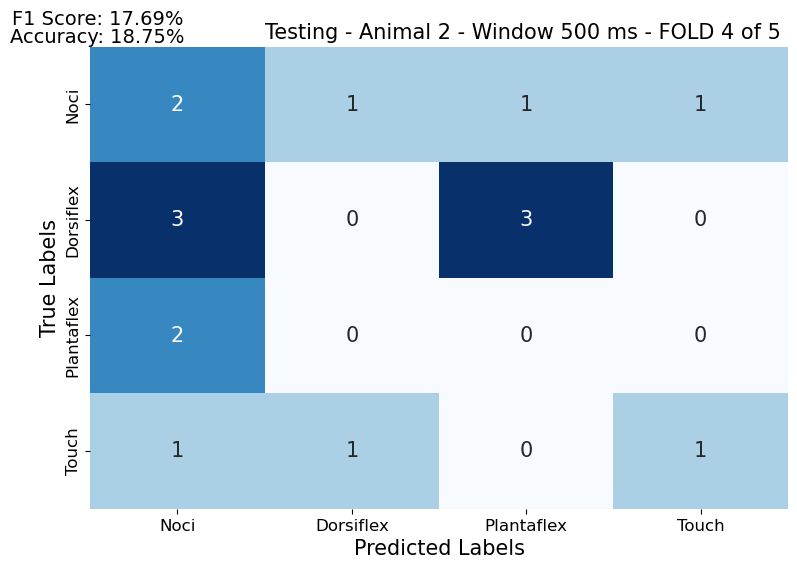

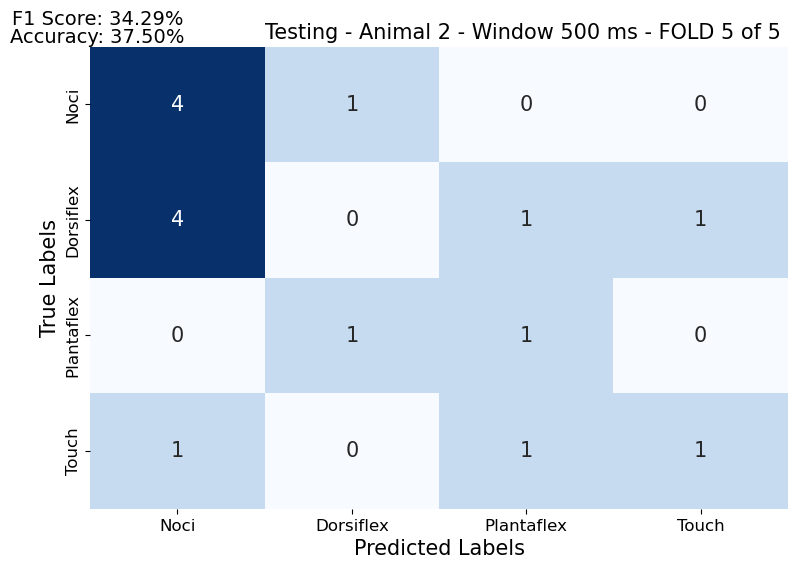

C:\Users\david\DatiTesiRAW\Github\PyPNRelay\toolbox\plots\Plot.py:459: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * (ppv * tpr) / (ppv + tpr)


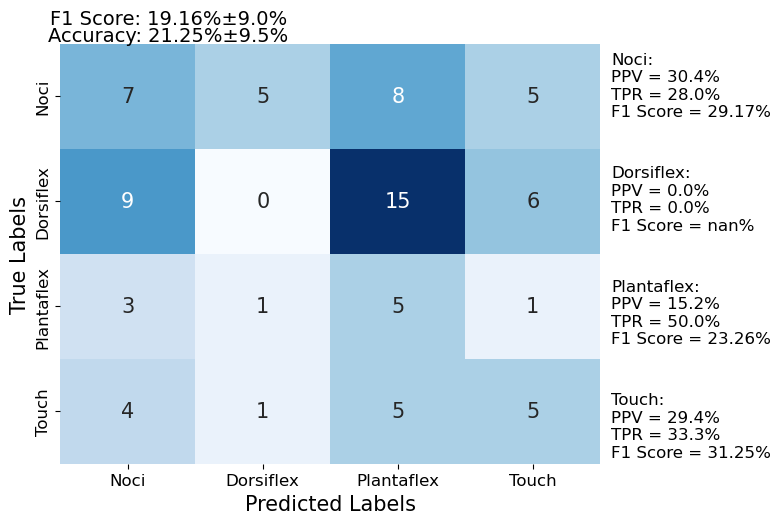

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 2/200ms/EEGNet_4_class_Animal 2_200ms_results.pickle


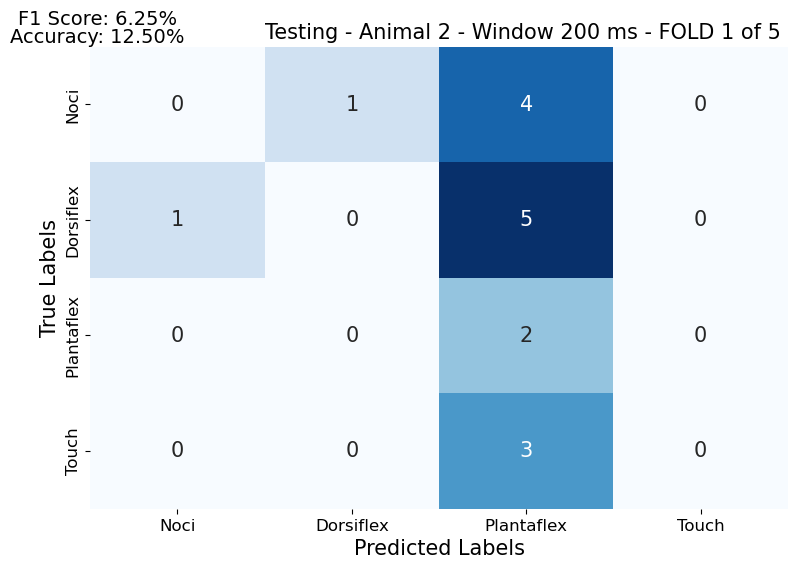

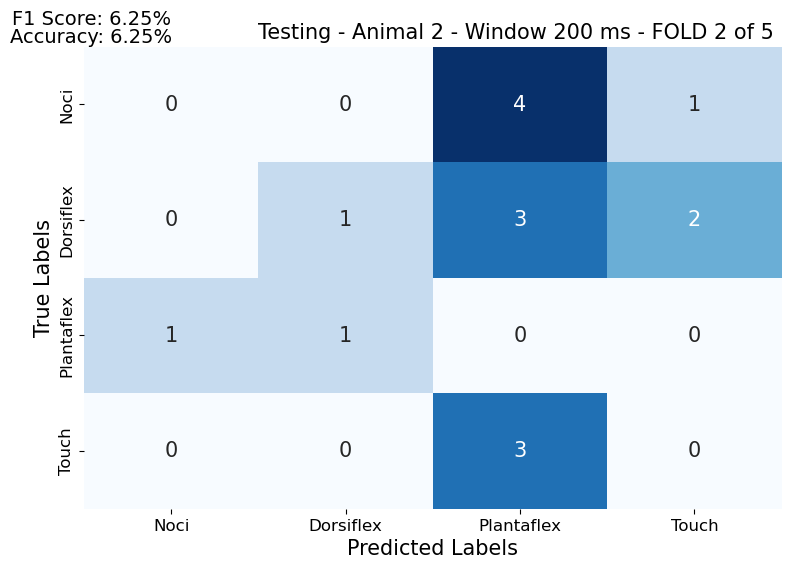

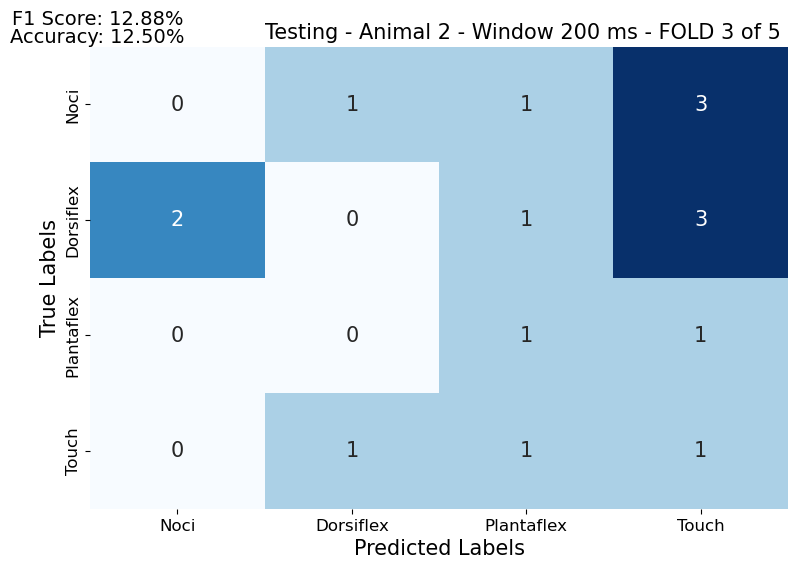

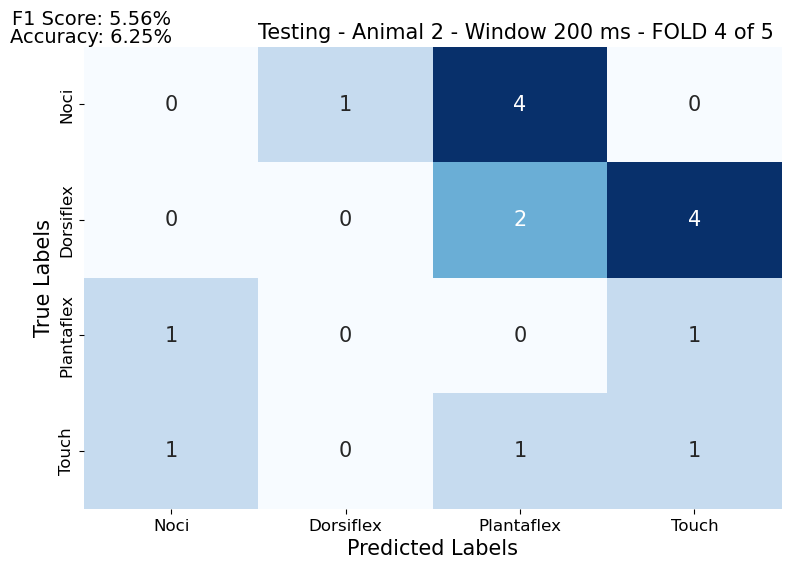

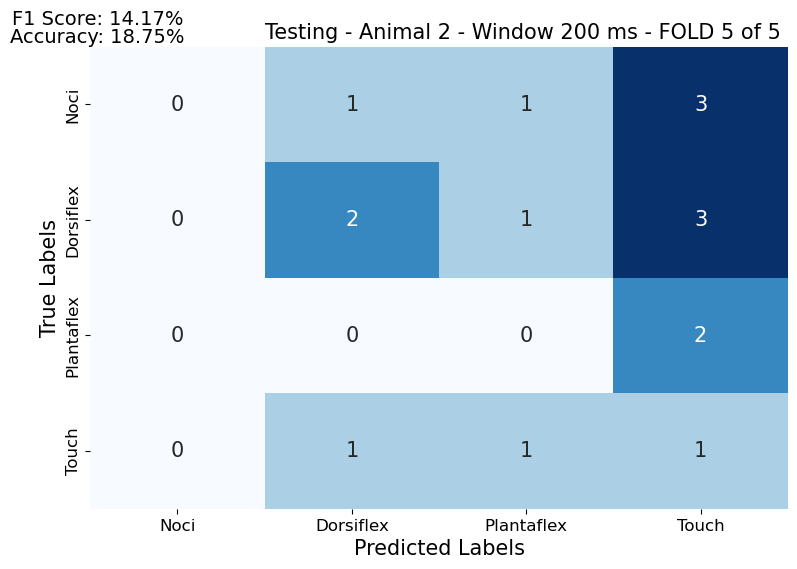

C:\Users\david\DatiTesiRAW\Github\PyPNRelay\toolbox\plots\Plot.py:459: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * (ppv * tpr) / (ppv + tpr)


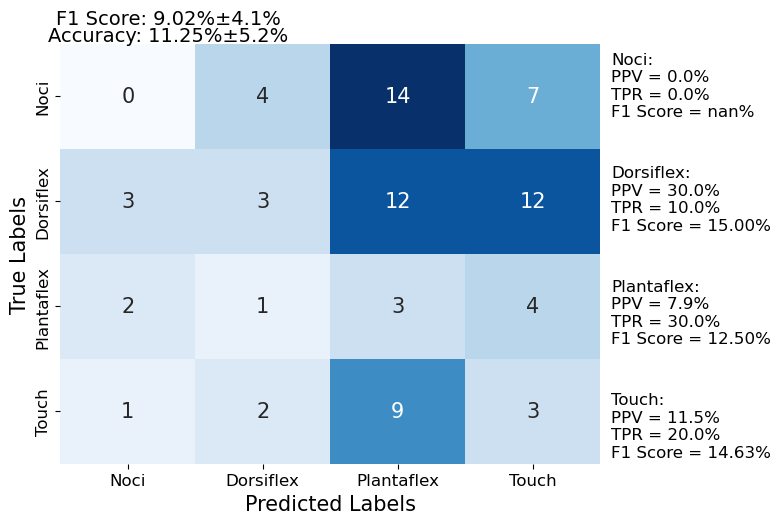

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 2/100ms/EEGNet_4_class_Animal 2_100ms_results.pickle


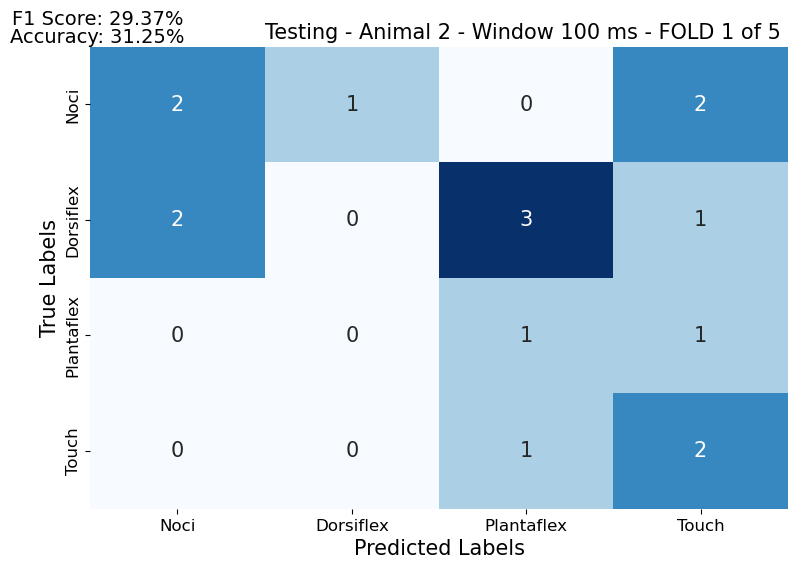

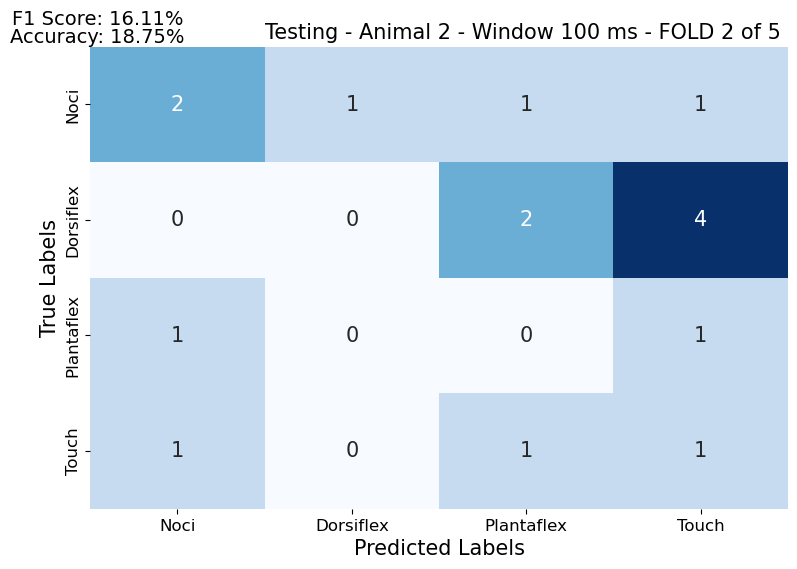

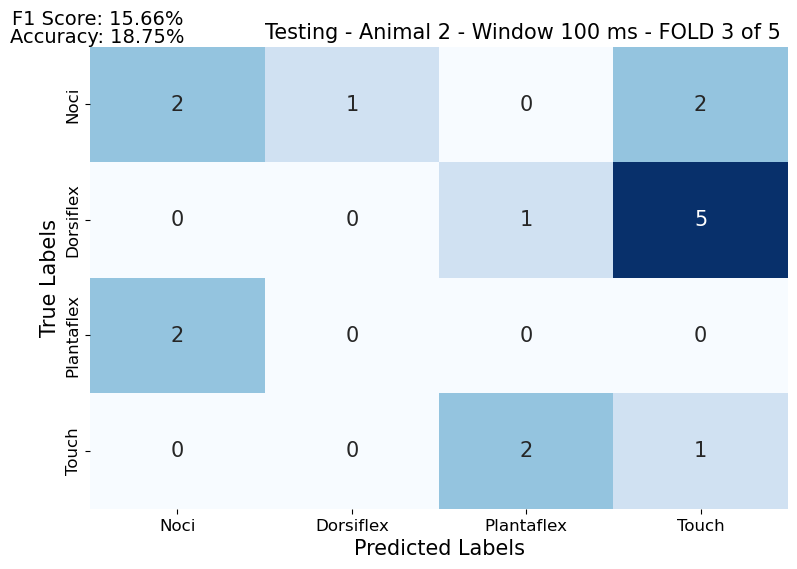

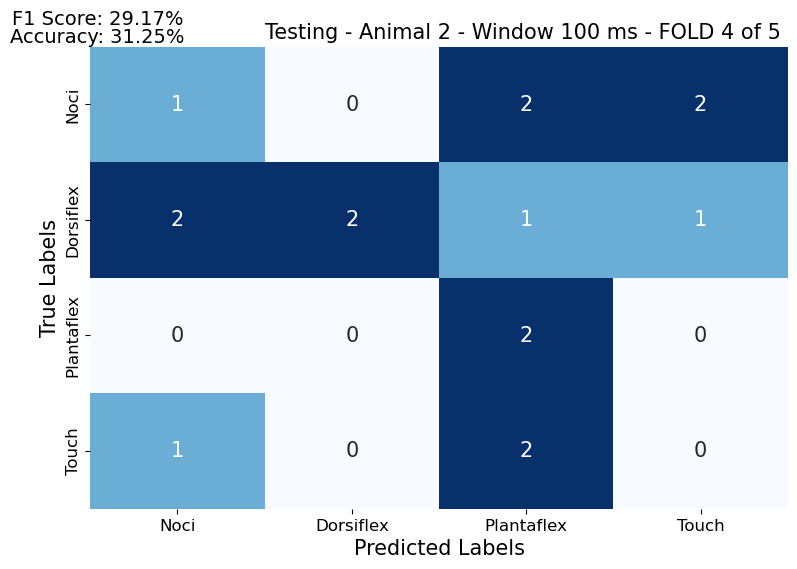

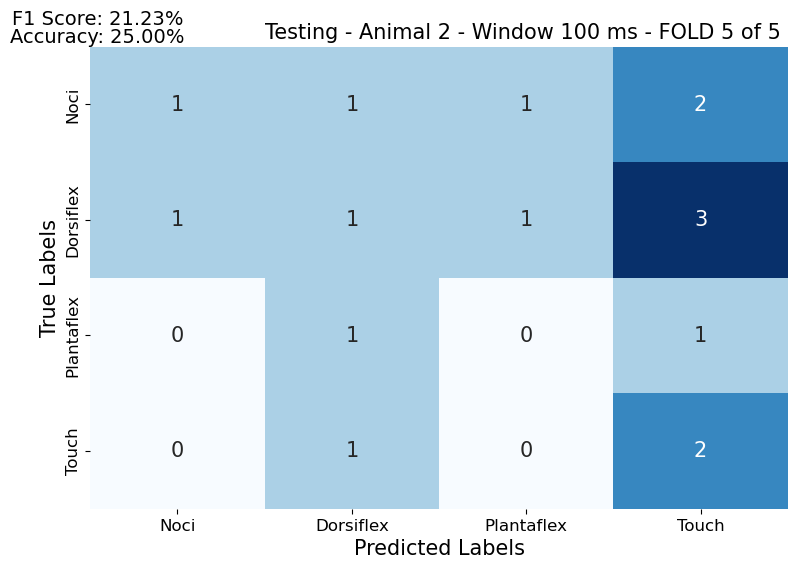

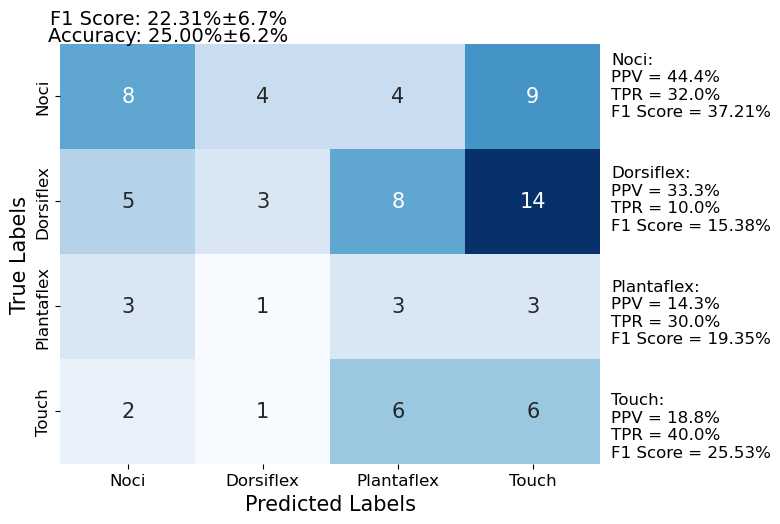

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 2/50ms/EEGNet_4_class_Animal 2_50ms_results.pickle


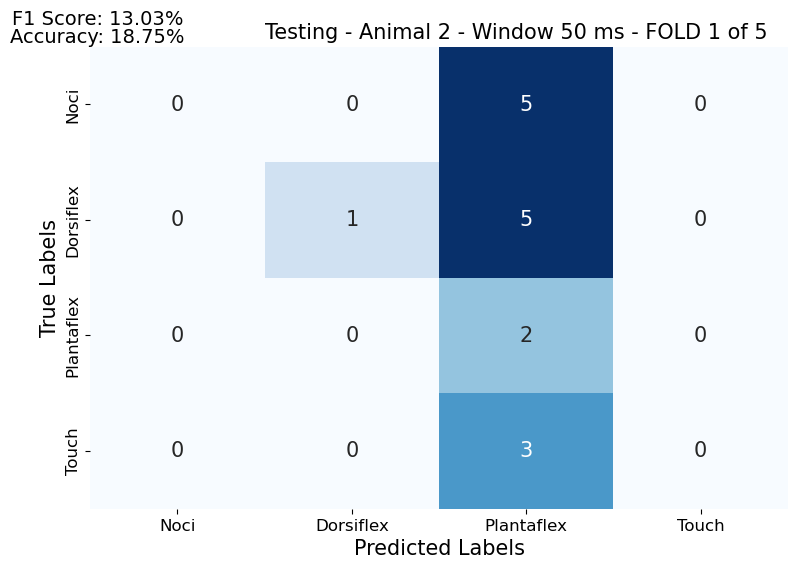

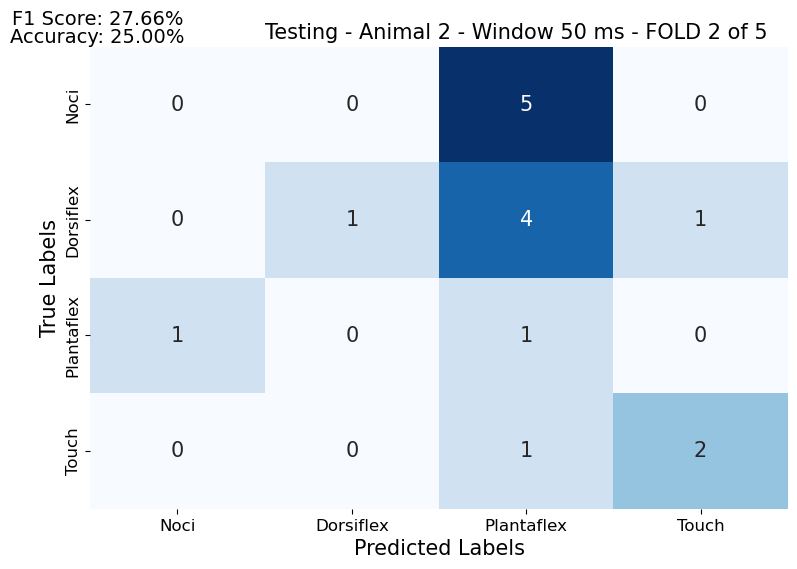

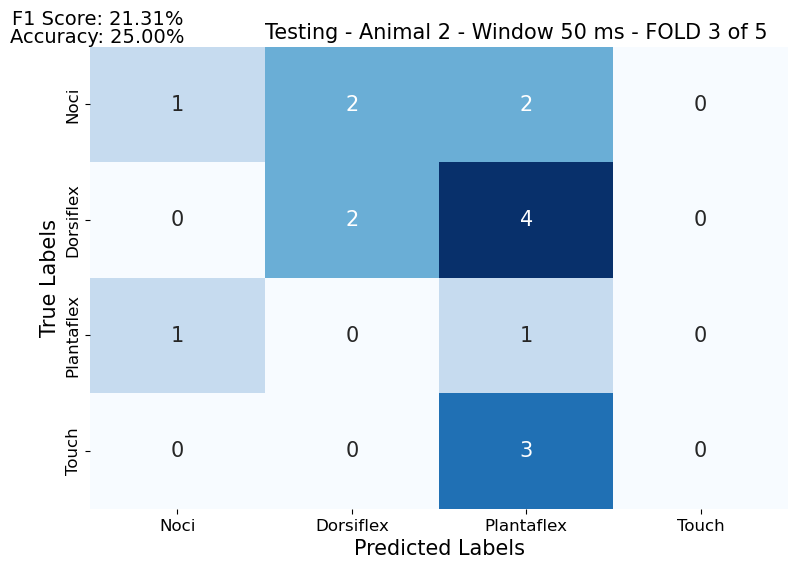

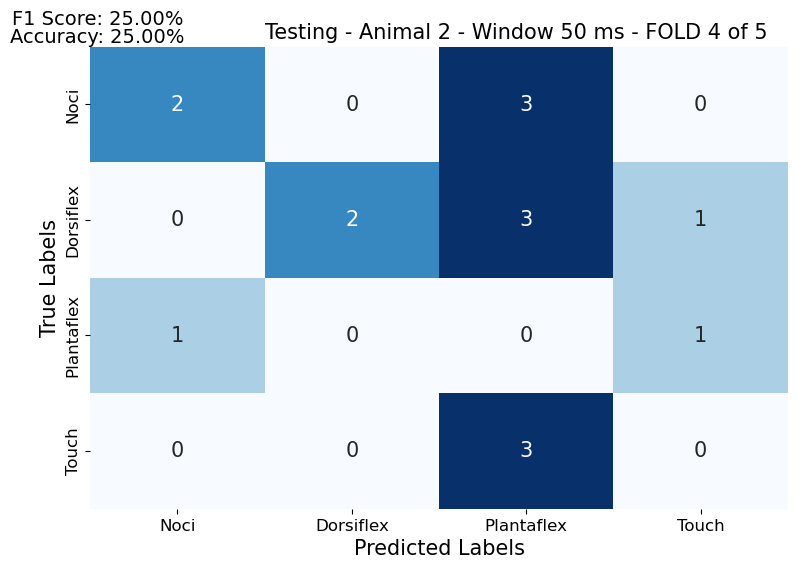

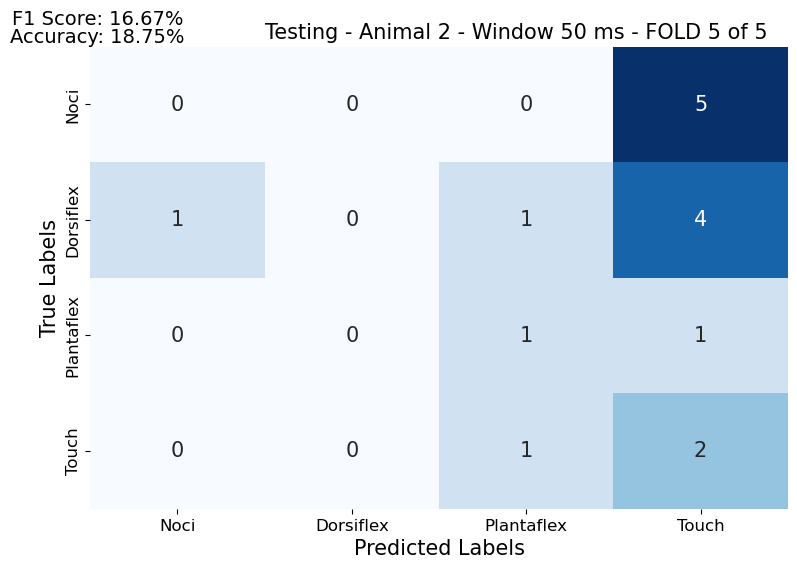

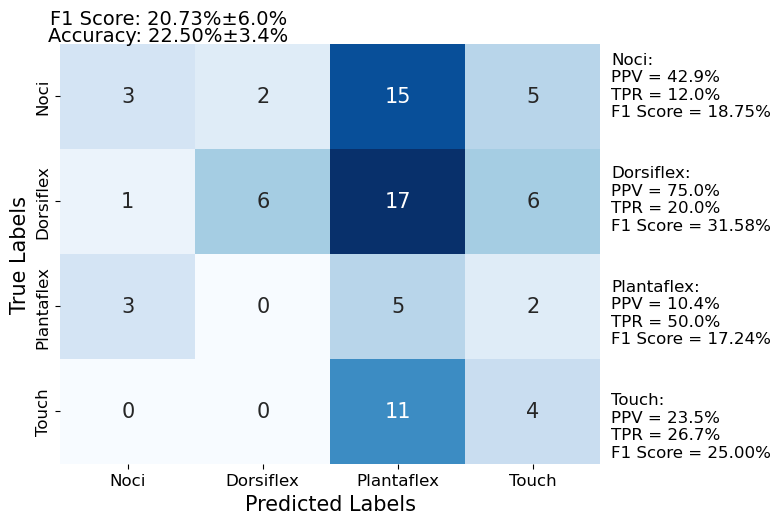

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 3/500ms/EEGNet_4_class_Animal 3_500ms_results.pickle


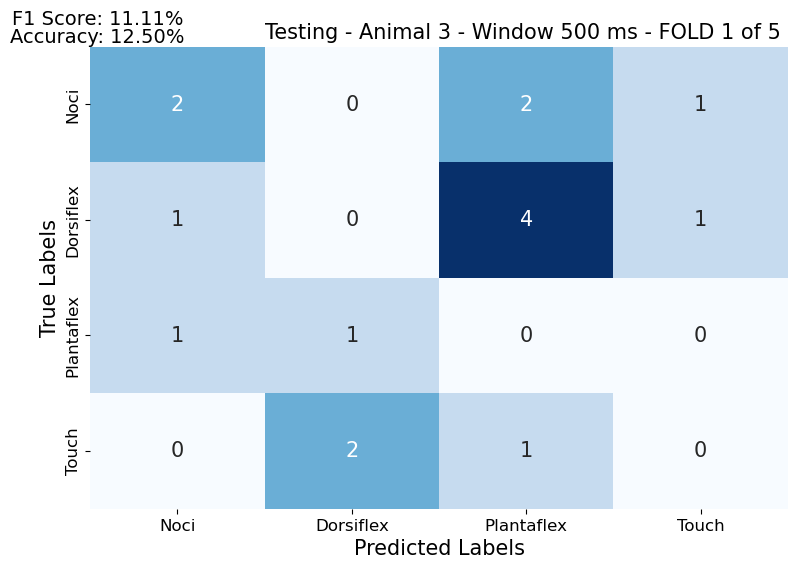

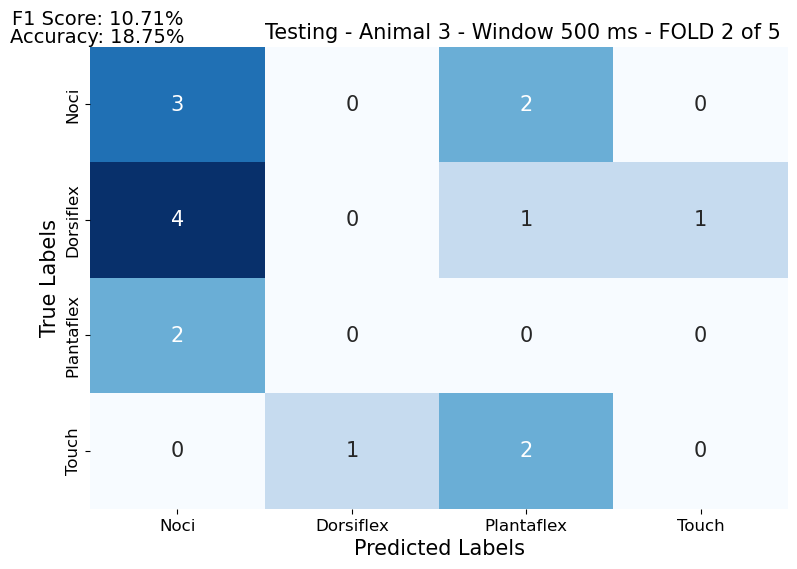

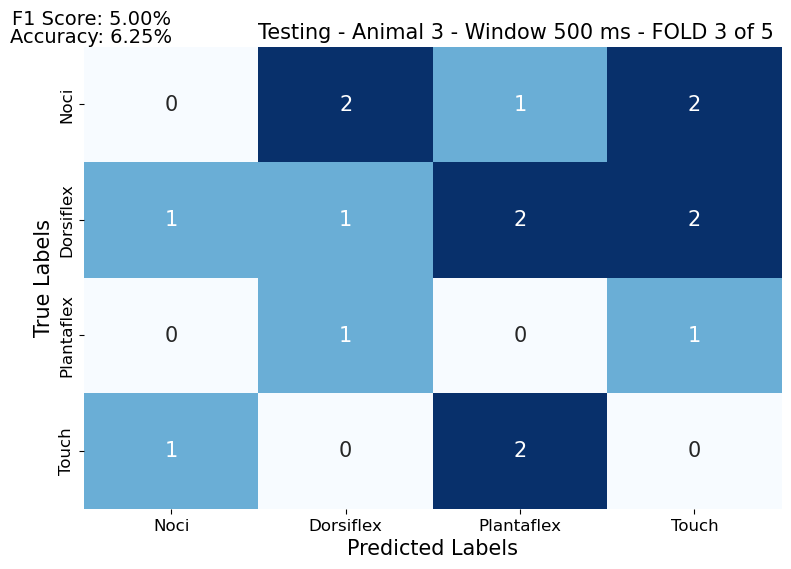

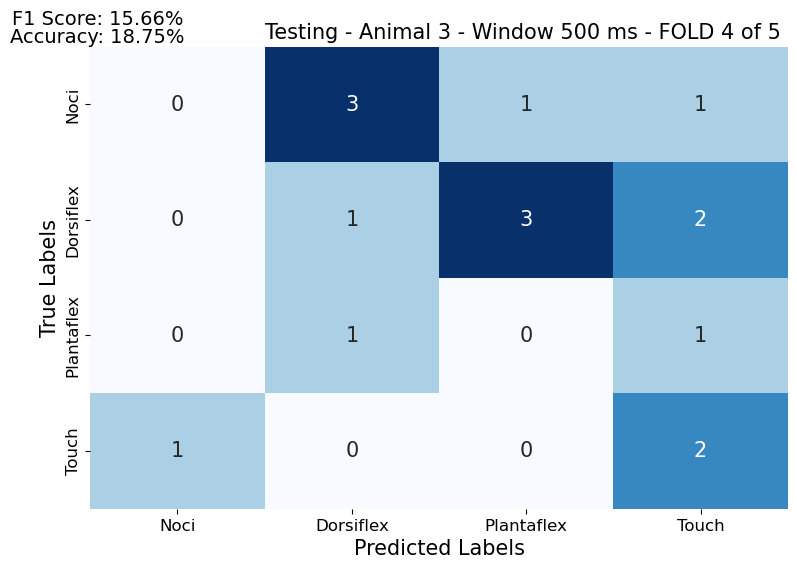

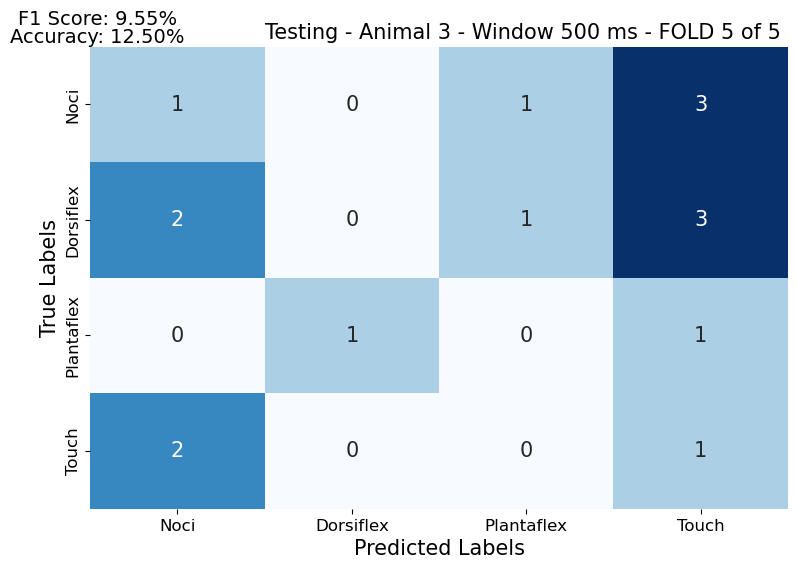

C:\Users\david\DatiTesiRAW\Github\PyPNRelay\toolbox\plots\Plot.py:459: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * (ppv * tpr) / (ppv + tpr)


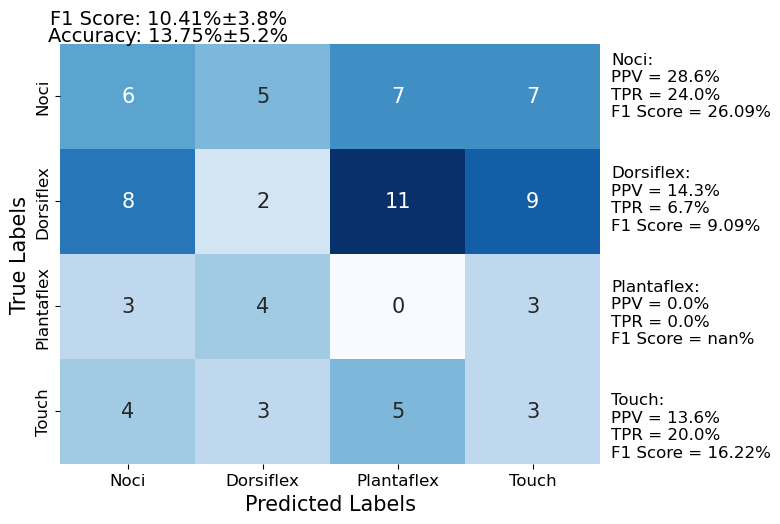

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 3/200ms/EEGNet_4_class_Animal 3_200ms_results.pickle


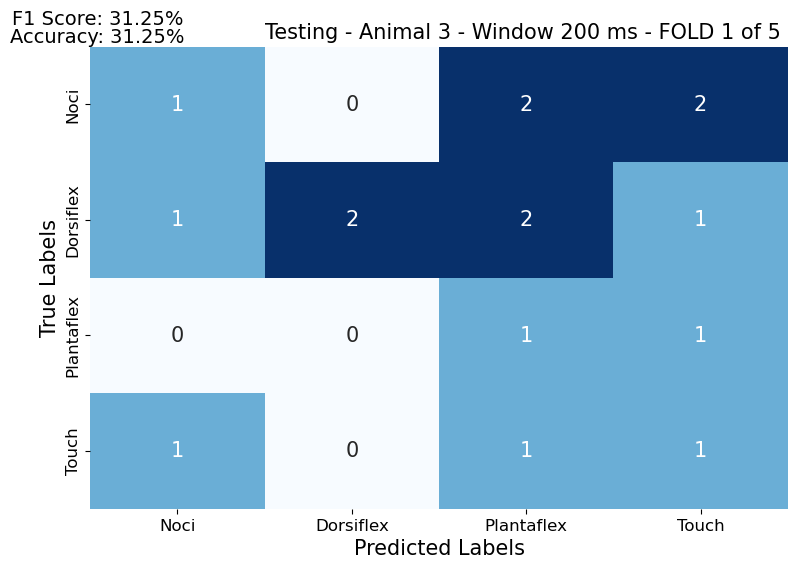

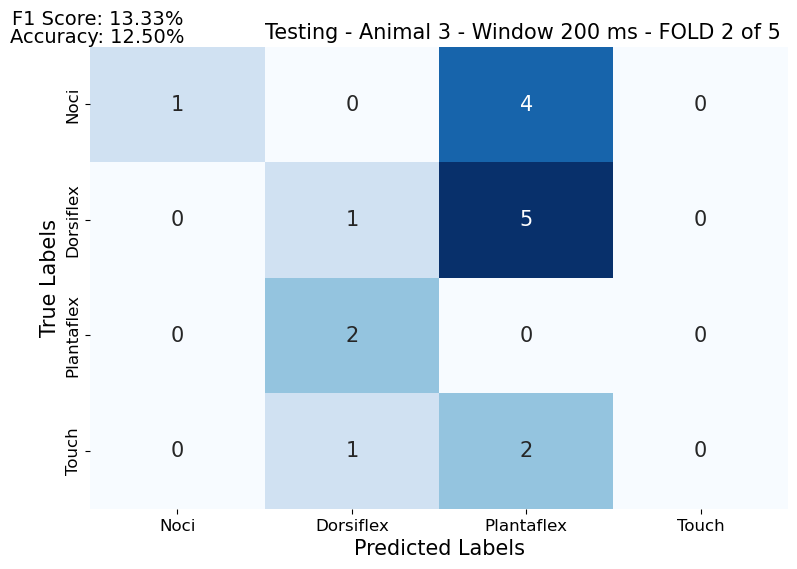

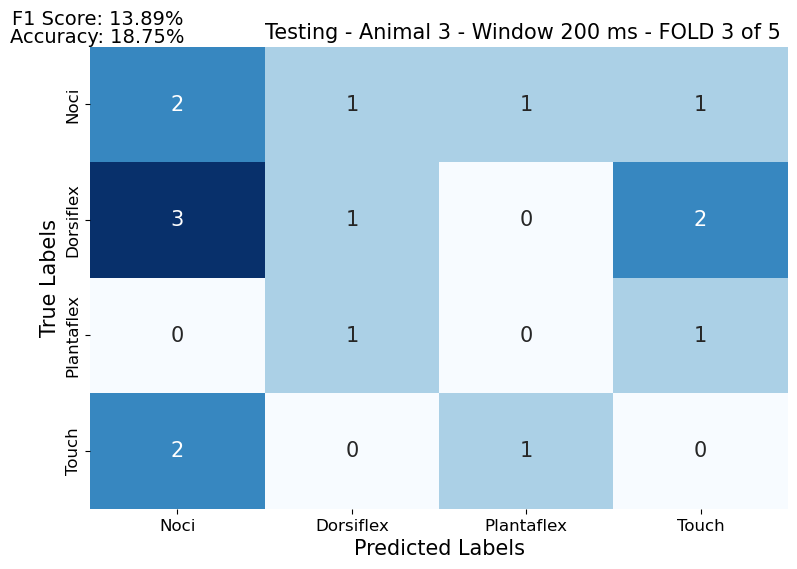

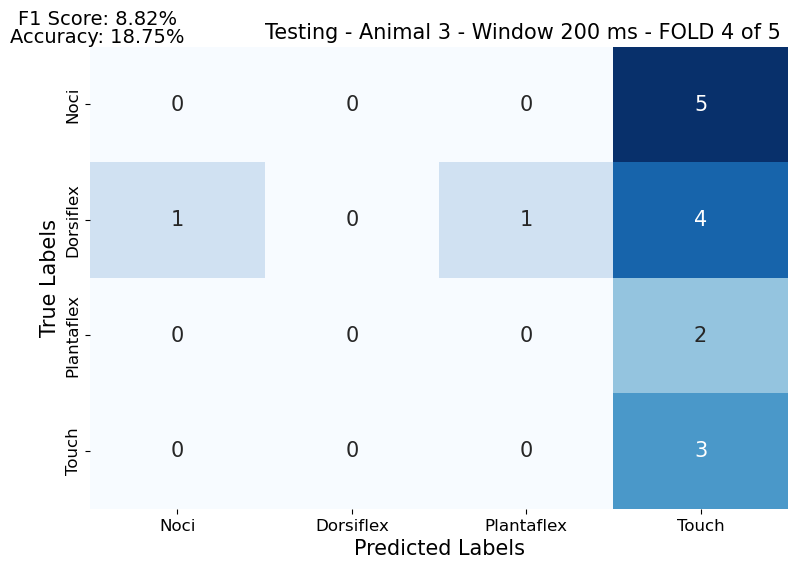

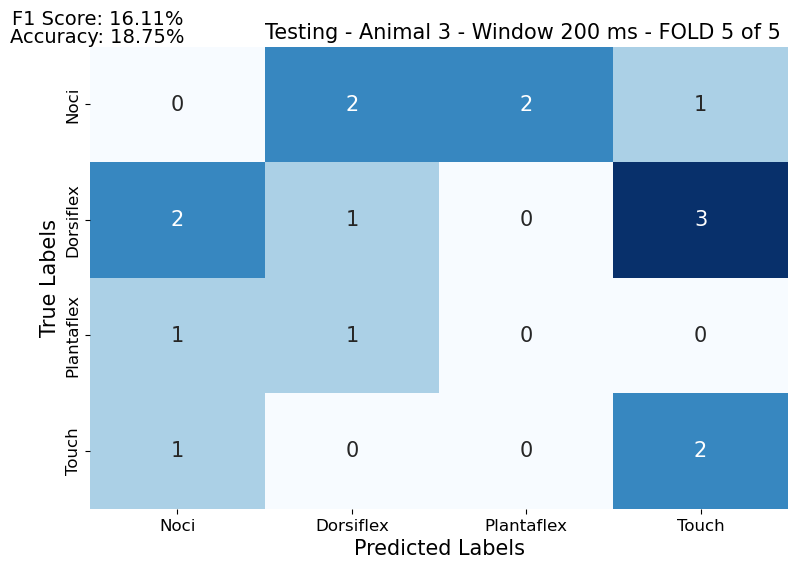

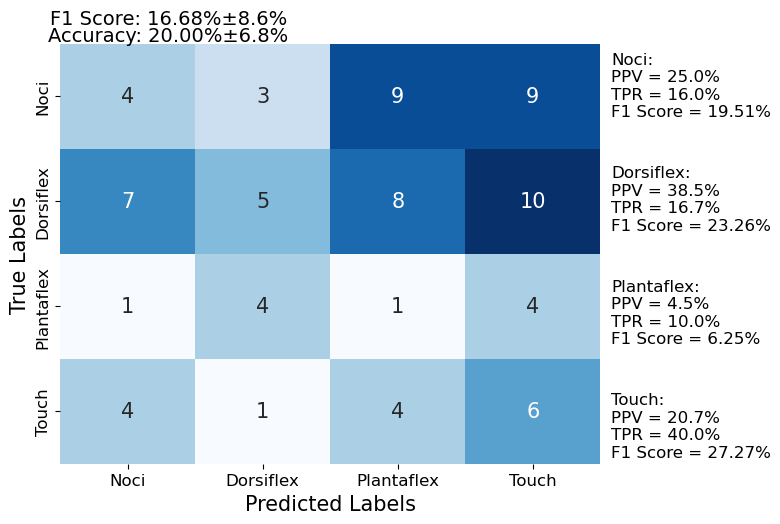

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 3/100ms/EEGNet_4_class_Animal 3_100ms_results.pickle


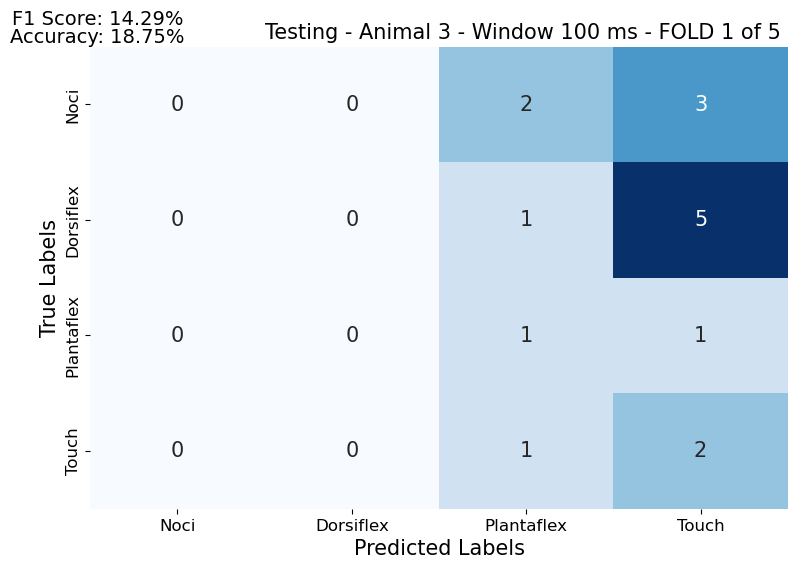

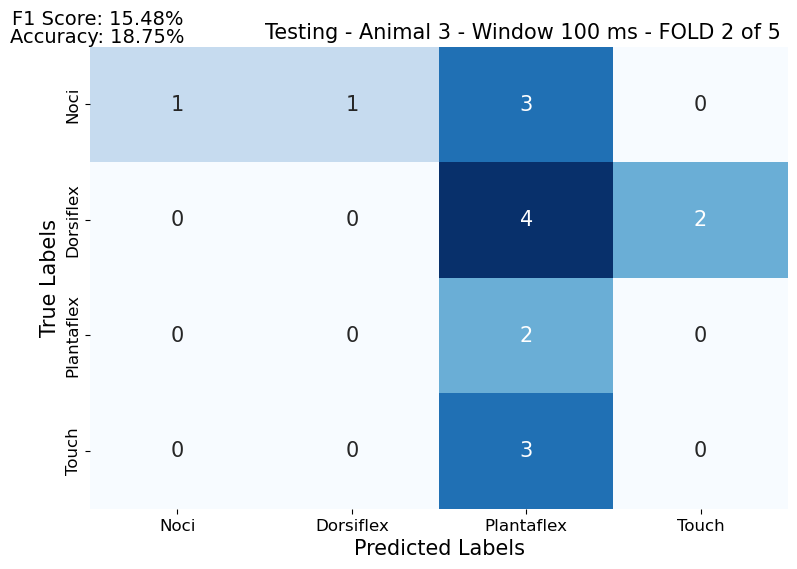

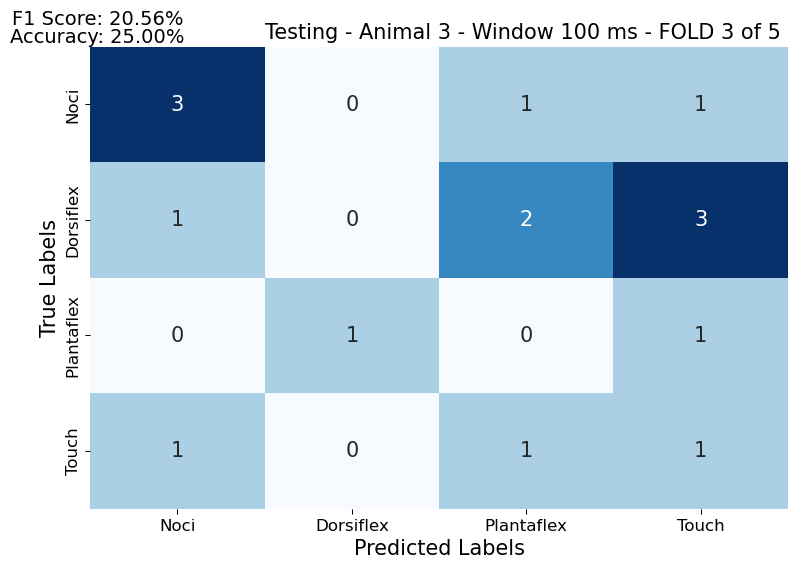

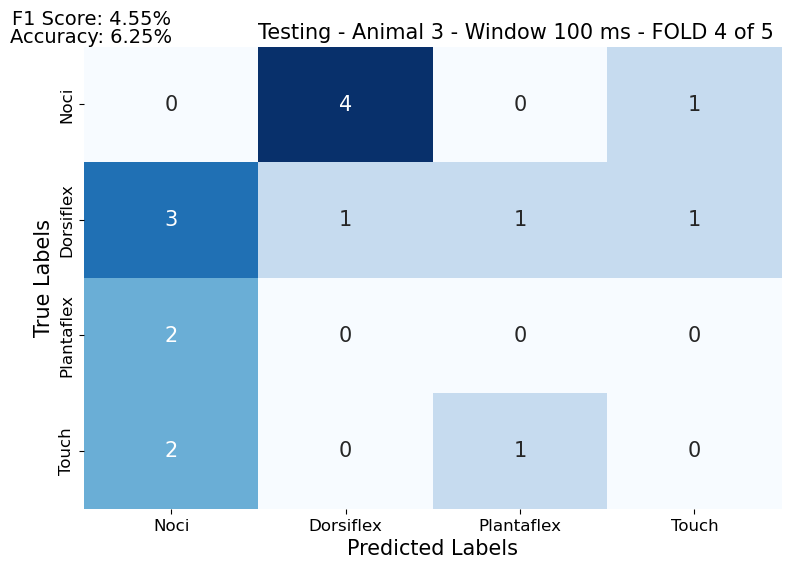

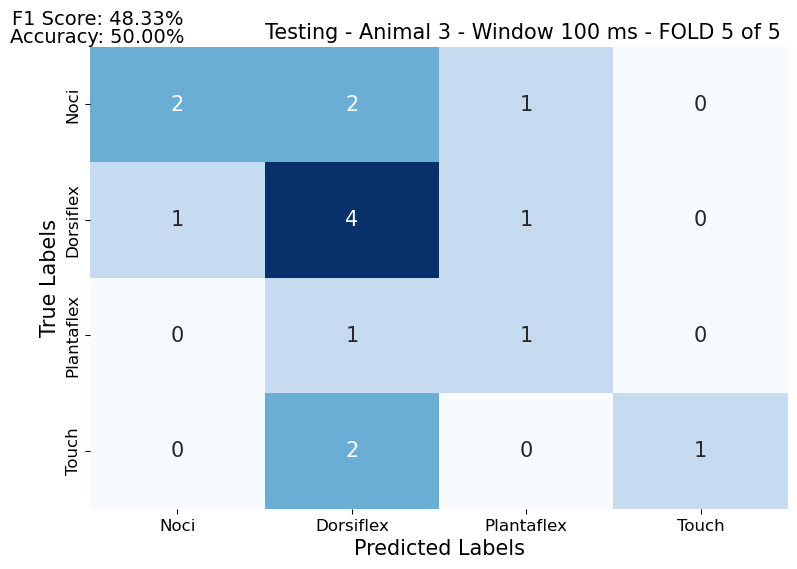

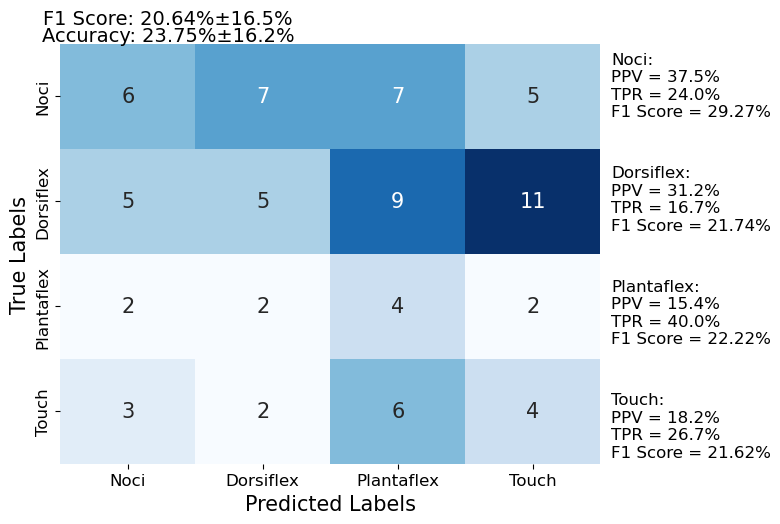

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 3/50ms/EEGNet_4_class_Animal 3_50ms_results.pickle


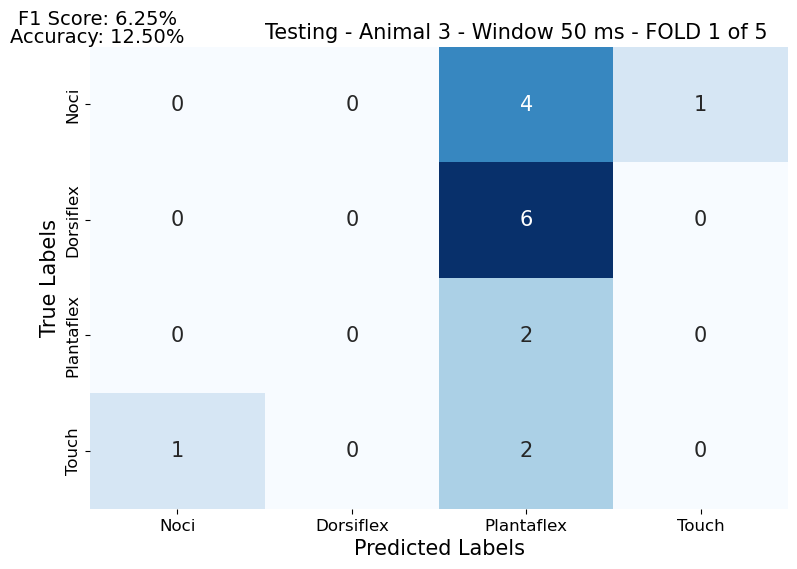

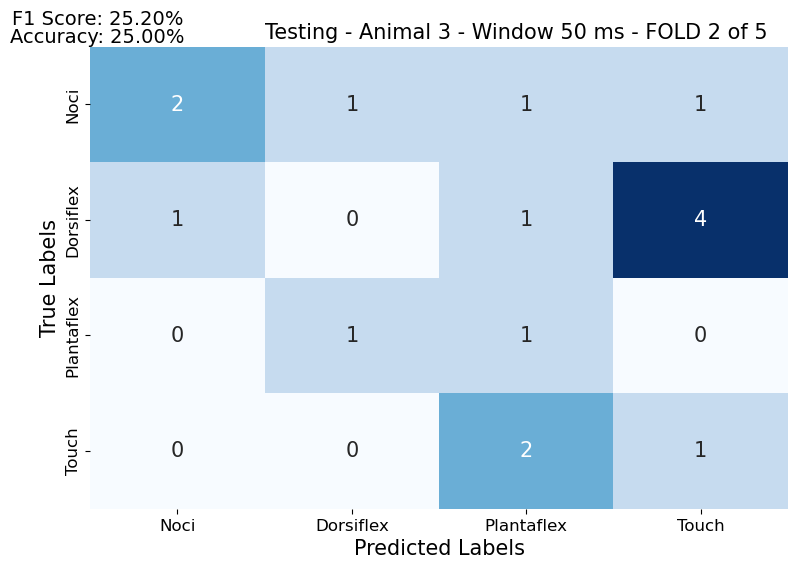

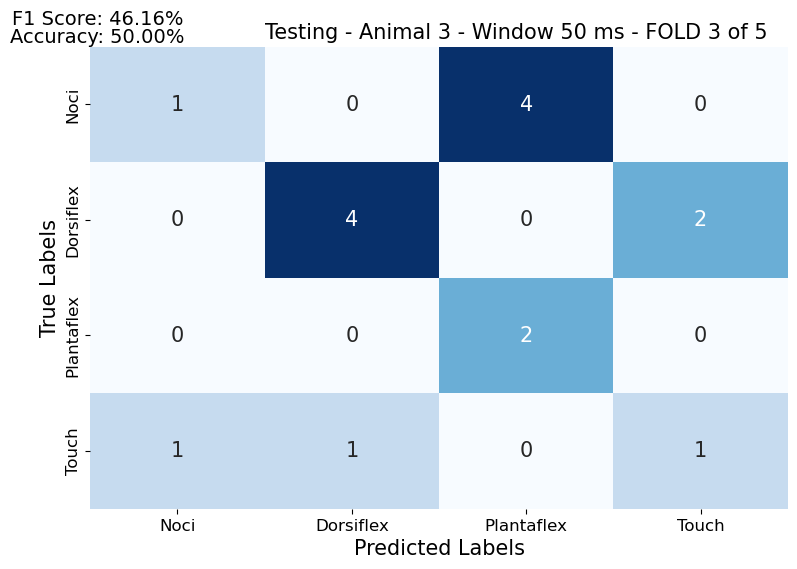

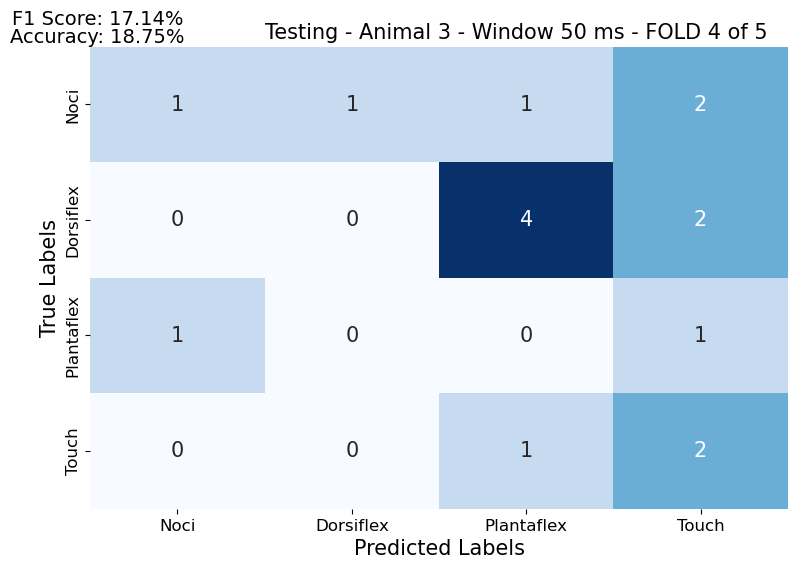

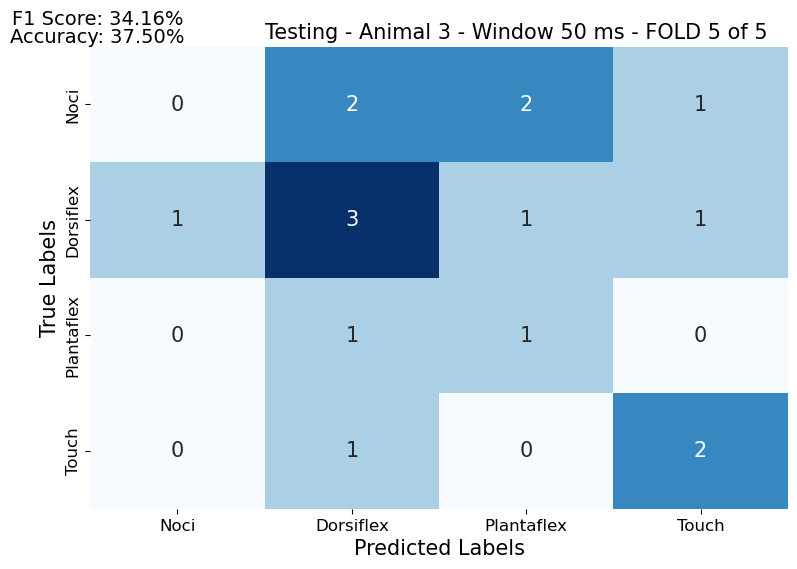

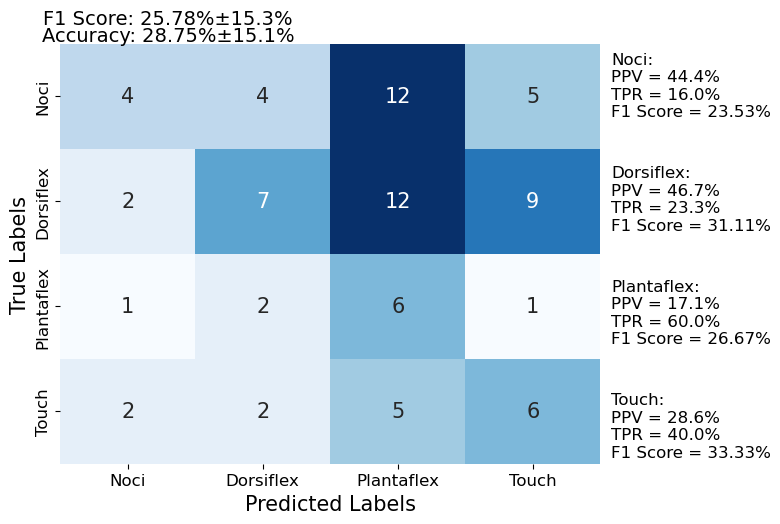

In [3]:
base_dir = os.getcwd()  # Get current working directory
base_folders = []

for classifier in classifiers:
    for animal in animals:
        for window in windows:
            base_folder = f'{base_dir}/results {dataset}/{classifier}/{n_classes}_class/{feature_selection}/'
            CM_plot(base_folder, classifier, animal, window, n_classes)


In [4]:
def F1_plot_perclass(base_folder,classifier_chosen, animal, window, n_classes):
    T_or_V='test_results'
    # Set the x-axis tick labels
    if n_classes==5:
        labels = ["Noci", "Dorsiflex", "Plantaflex", "Touch", "Rest"]
        dist=0.20
    else:
        labels = ["Noci", "Dorsiflex", "Plantaflex", "Touch"]
        dist=0.27
        
    # Initialize an empty list to store individual confusion matrices
    matrices = []
    
    pickle_file_folder = base_folder + animal+'/' + window+'ms/'
    
    pickle_file_path = pickle_file_folder + classifier_chosen+'_'+str(n_classes)+'_class_' + animal +'_'+ window + 'ms_results.pickle'
    
    output_cm = base_folder + 'Plot Per Class'
    
    if not os.path.exists(output_cm):
            os.makedirs(output_cm)
            
    print(pickle_file_path)

    # Load the pickle file
    with open(pickle_file_path, 'rb') as pickle_file:
        results_dict = pickle.load(pickle_file)

        # Check if 'test_results' dictionary exists and contains 'test_confusion_matrix'
        if 'test_results' in results_dict and 'test_confusion_matrix' in results_dict['test_results']:

            # Get the list of individual confusion matrices
            matrices = results_dict[T_or_V]['test_confusion_matrix']

            # Combine individual confusion matrices and get mean and std of the K-CVs
            combined_matrix = np.sum(matrices, axis=0)

            mean_accuracy = np.mean(results_dict[T_or_V]['test_accuracy'])*100
            mean_f1_score = np.mean(results_dict[T_or_V]['test_f1_score'])*100

            std_accuracy = np.std(results_dict[T_or_V]['test_accuracy'], ddof=1)*100
            std_f1_score = np.std(results_dict[T_or_V]['test_f1_score'], ddof=1)*100

            for fold, matrix in enumerate(matrices):

                title=f"Testing - {animal} - Window {window} ms - FOLD {fold+1} of {len(matrices)}"

                f1_score=results_dict[T_or_V]['test_f1_score'][fold]*100
                accuracy=results_dict[T_or_V]['test_accuracy'][fold]*100       

                # Save the individual confusion matrix

                output_file = f'{base_folder}/{title}.png'
                plt.figure(figsize=(9,6))            
                sns.heatmap(matrix, annot=True, fmt='g', cmap='Blues', cbar=False,  annot_kws={"size": 15}, xticklabels=labels, yticklabels=labels)
                plt.xticks(fontsize=12)
                plt.yticks(fontsize=12)

                plt.title(title, loc='left', x=0.25, fontsize=15)
                plt.xlabel('Predicted Labels', fontsize=15)
                plt.ylabel('True Labels', fontsize=15)

                # Annotate the plot with F1 score and accuracy
                plt.text(0.01, 1.06, f"F1 Score: {f1_score:.2f}%", ha='center', va='center', fontsize=14, transform=plt.gca().transAxes)
                plt.text(0.01, 1.02, f"Accuracy: {accuracy:.2f}%", ha='center', va='center', fontsize=14, transform=plt.gca().transAxes)

                output_file = output_cm +'/'+ title  # Replace with the desired output path
                plt.savefig(output_file)
                plt.show()
                plt.close()
                
            # Calculate precision, recall, and F1 score for each class
            ppv_per_class = []
            tpr_per_class = []
            f1_per_class = []
                      
            for cls in range(len(combined_matrix)):
                true_positive = combined_matrix[cls, cls]
                false_positive = np.sum(combined_matrix[:, cls]) - true_positive
                false_negative = np.sum(combined_matrix[cls, :]) - true_positive
                true_negative = np.sum(combined_matrix) - (true_positive + false_positive + false_negative)

                # Positive Predictive Value (PPV) or Precision
                ppv = true_positive / (true_positive + false_positive) *100
                ppv_per_class.append(ppv)

                # True Positive Rate (TPR) or Sensitivity or Recall
                tpr = true_positive / (true_positive + false_negative)*100
                tpr_per_class.append(tpr)

                # F1 Score
                f1 = 2 * (ppv * tpr) / (ppv + tpr)
                f1_per_class.append(f1)

            # Create a heatmap for the combined confusion matrix
            plt.figure(figsize=(9,6))
            plt.subplots_adjust(left=0.15, right=0.75, top=0.85, bottom=0.15)  # Adjust these values as needed

            sns.heatmap(combined_matrix, annot=True, fmt='g', cmap='Blues', cbar=False,  annot_kws={"size": 15}, xticklabels=labels, yticklabels=labels)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.xlabel('Predicted Labels', fontsize=15)
            plt.ylabel('True Labels', fontsize=15)


            title=f"Testing - {animal} - Window {window} ms - Sum of {len(matrices)} FOLDs"
            #plt.title(title, loc='left', x=0.25, fontsize=15)
            plt.text(0.2, 1.06, f"F1 Score: {mean_f1_score:.2f}%±{std_f1_score:.1f}%", ha='center', va='center', fontsize=14, transform=plt.gca().transAxes)
            plt.text(0.2, 1.02, f"Accuracy: {mean_accuracy:.2f}%±{std_accuracy:.1f}%", ha='center', va='center', fontsize=14, transform=plt.gca().transAxes)       

            for cls in range(len(combined_matrix)):
                plt.text(1.02, 0.9 - cls*dist, f"{labels[cls]}:\nPPV = {ppv_per_class[cls]:.1f}%\nTPR = {tpr_per_class[cls]:.1f}%\nF1 Score = {f1_per_class[cls]:.2f}%", ha='left', va='center', fontsize=12, transform=plt.gca().transAxes)


                #print(f"Class {cls + 1}: PPV = {ppv_per_class[cls]:.1f}, TPR = {tpr_per_class[cls]:.1f}, F1 Score = {f1_per_class[cls]:.2f}")


            # Save the combined confusion matrix as an image
            output_file = output_cm  +'/'+ title  # Replace with the desired output path
            plt.savefig(output_file)
            plt.show()
            plt.close()

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 1/500ms/EEGNet_4_class_Animal 1_500ms_results.pickle


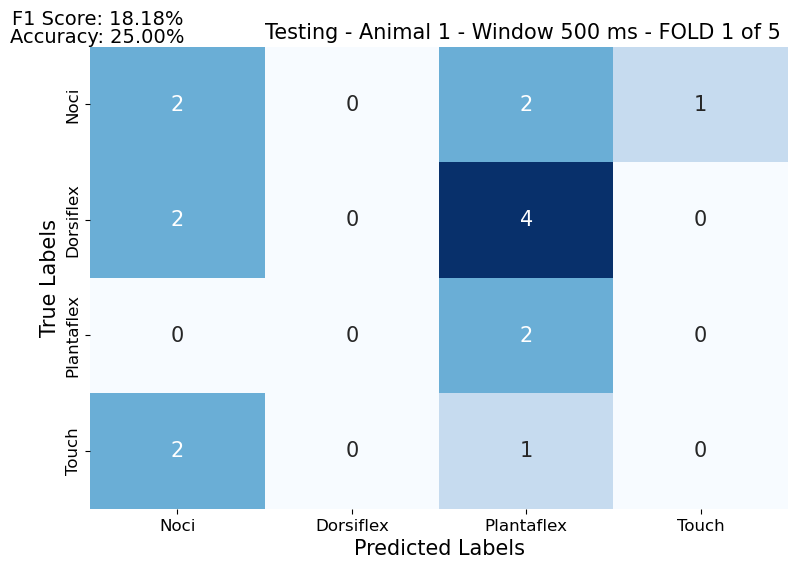

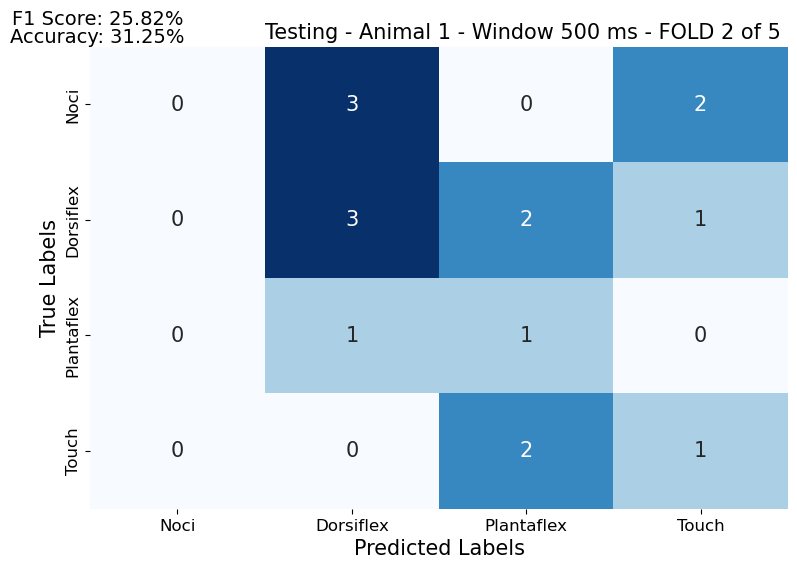

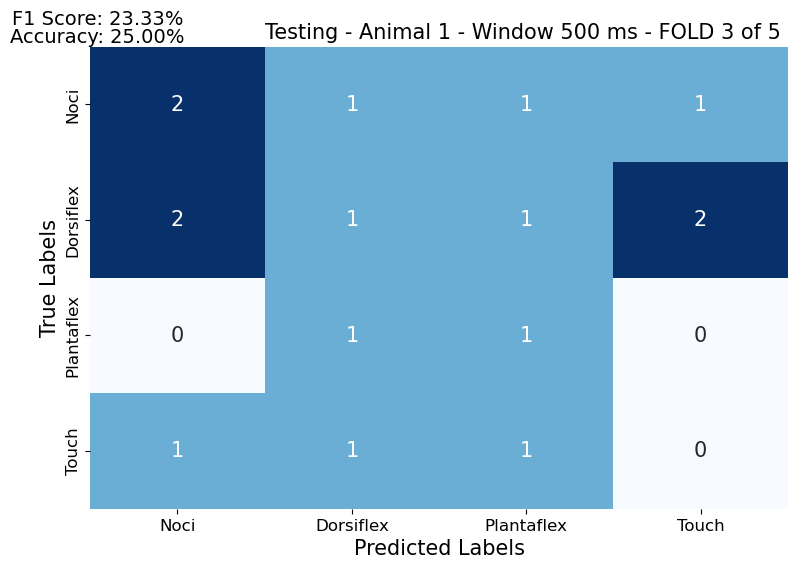

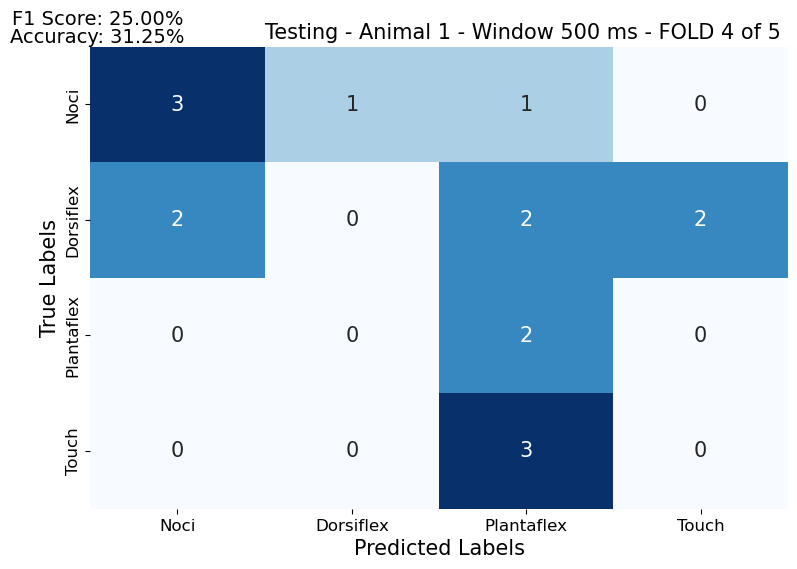

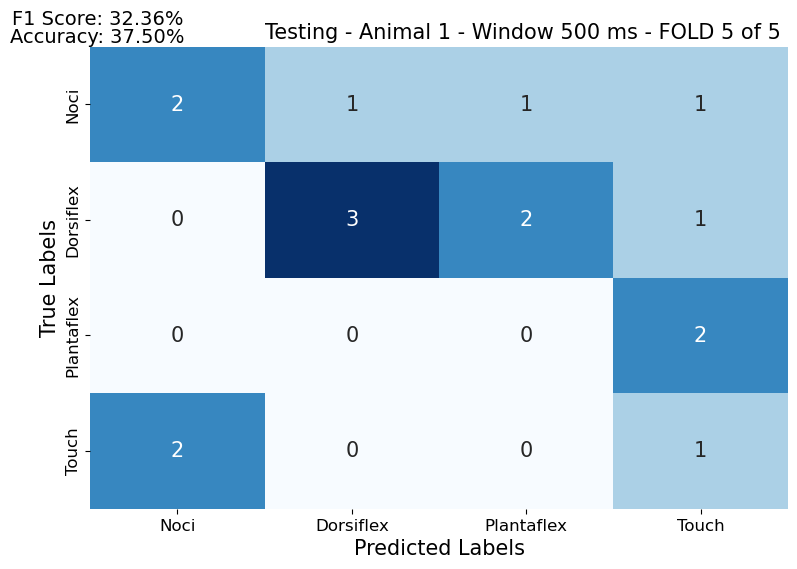

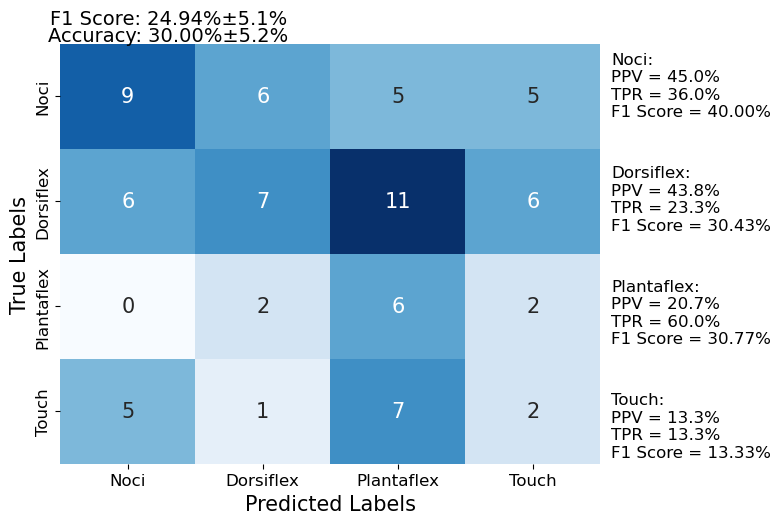

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 1/200ms/EEGNet_4_class_Animal 1_200ms_results.pickle


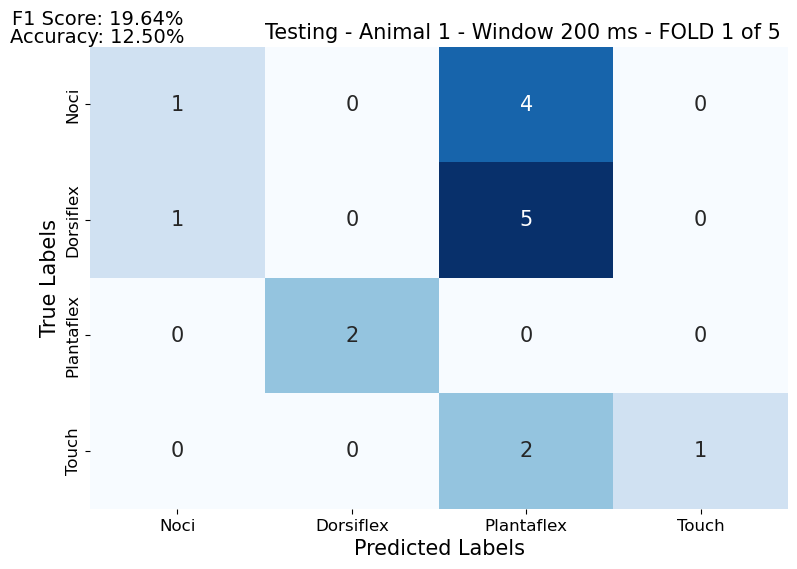

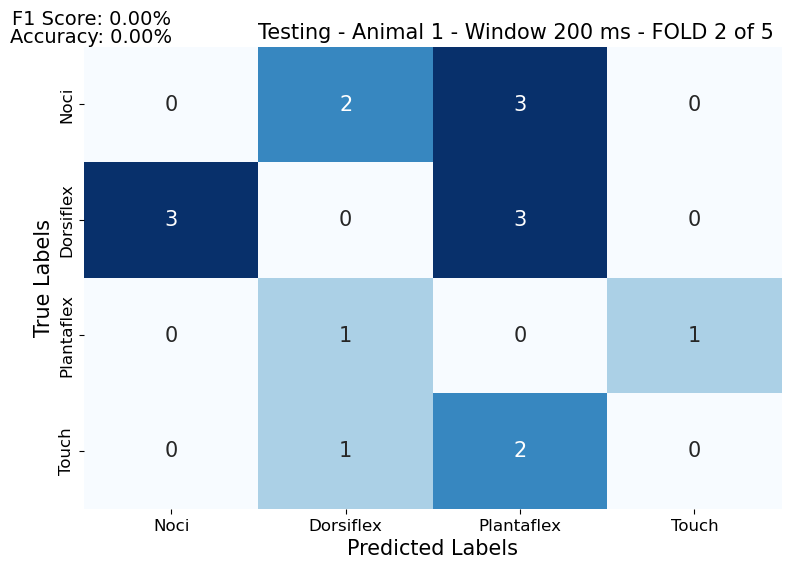

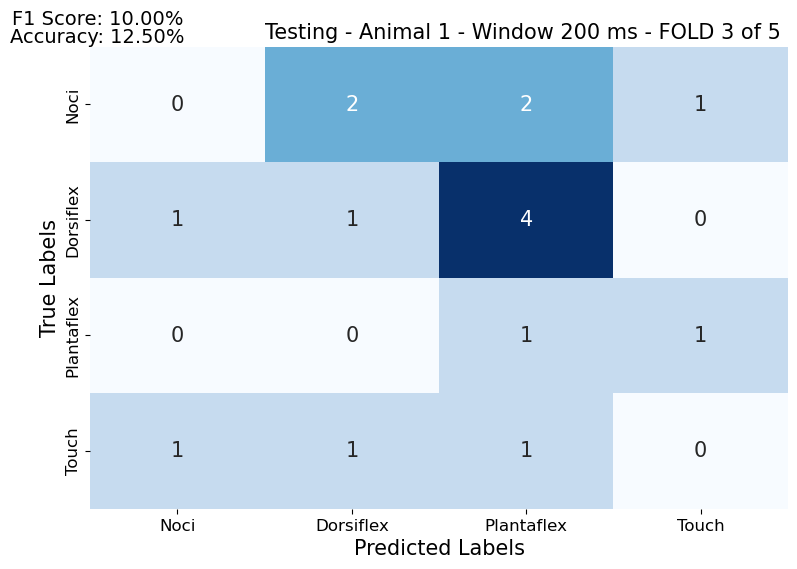

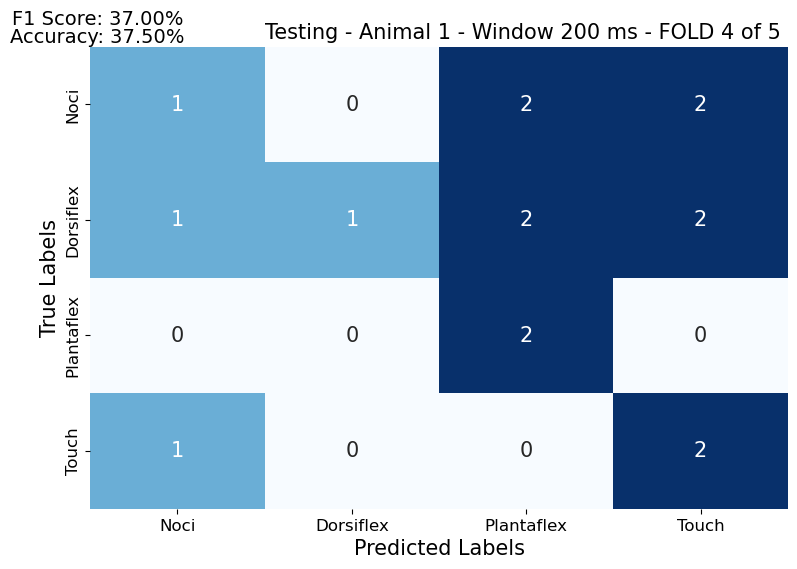

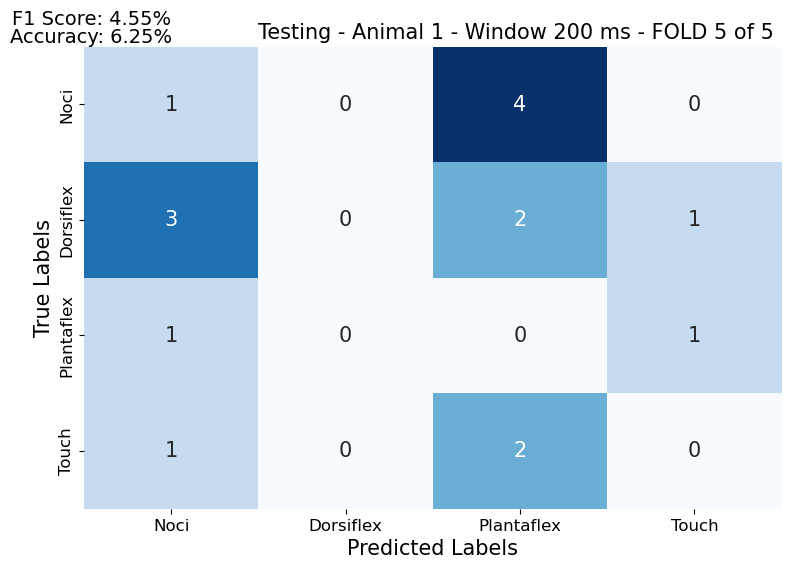

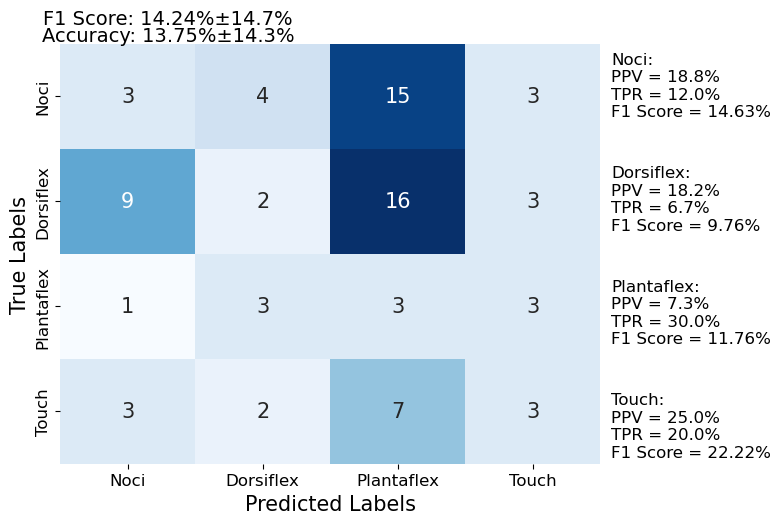

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 1/100ms/EEGNet_4_class_Animal 1_100ms_results.pickle


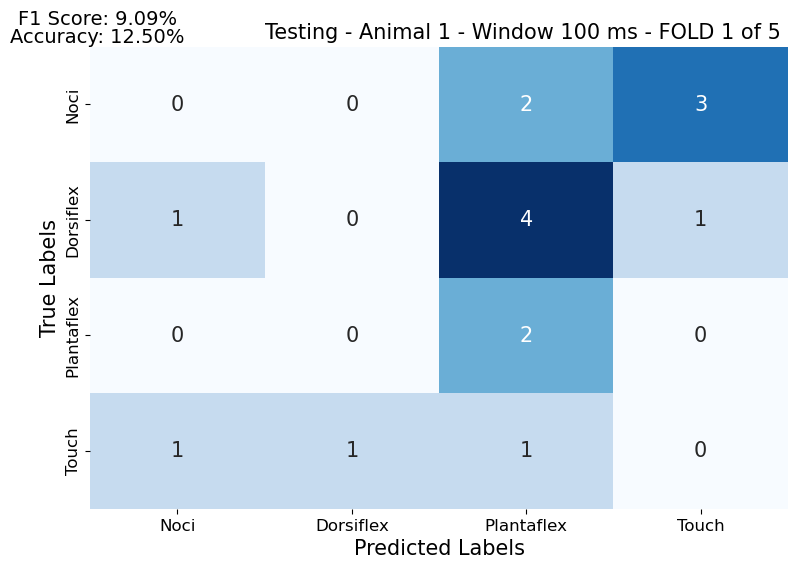

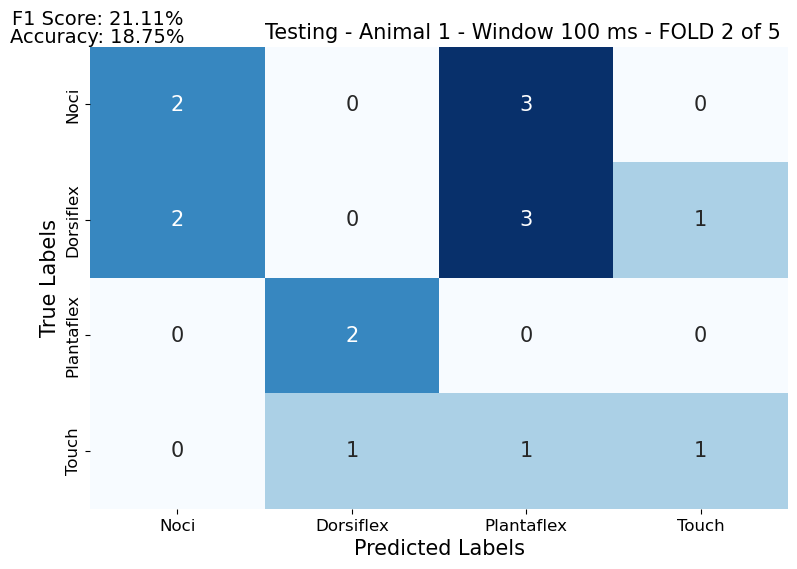

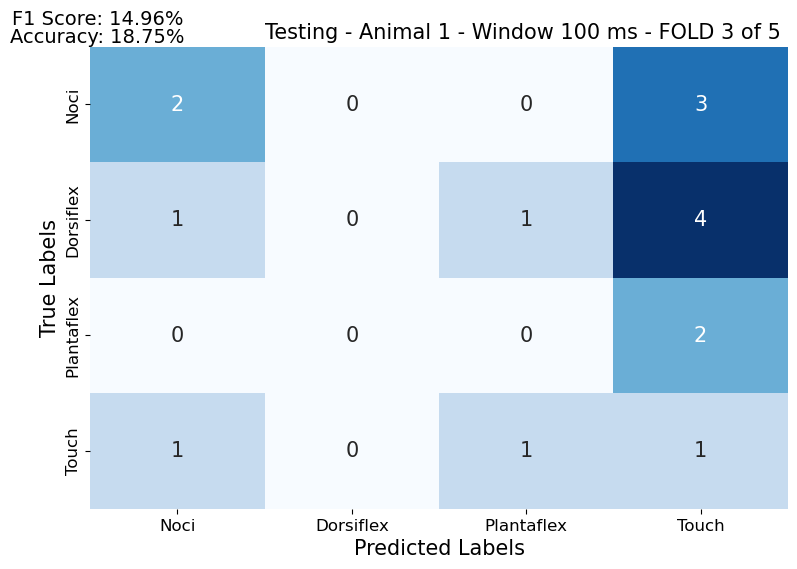

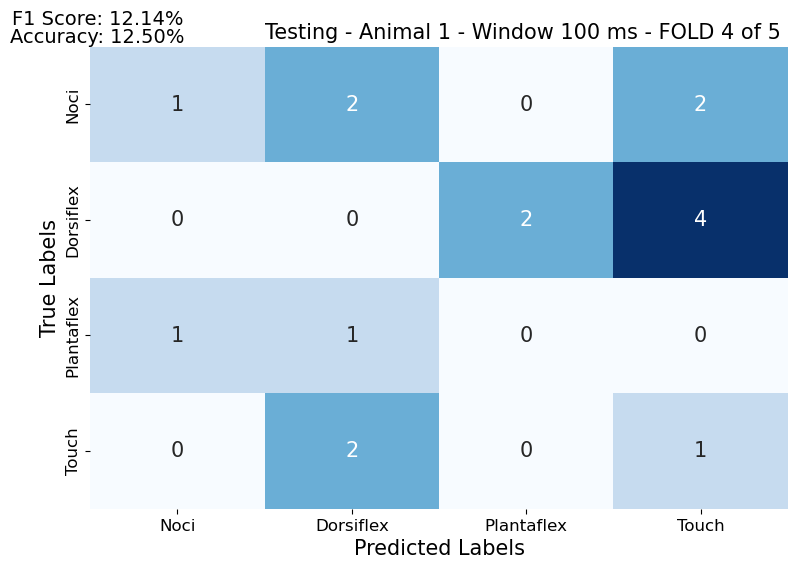

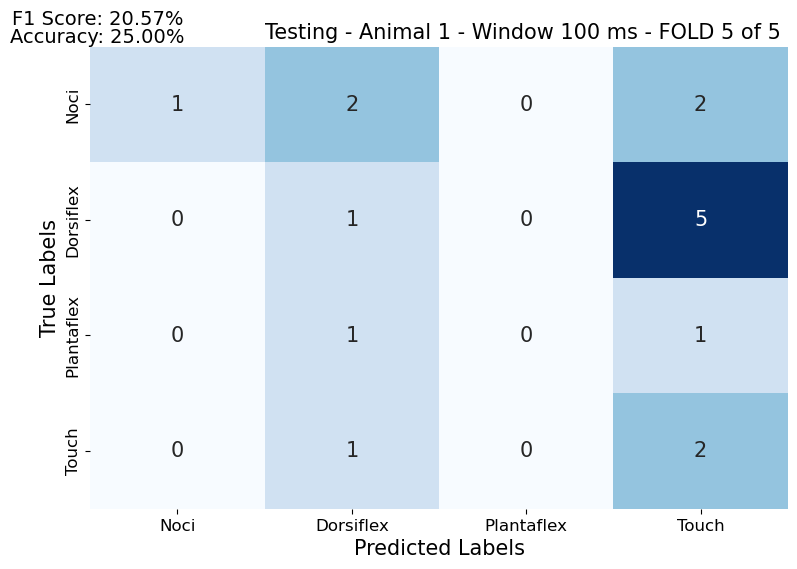

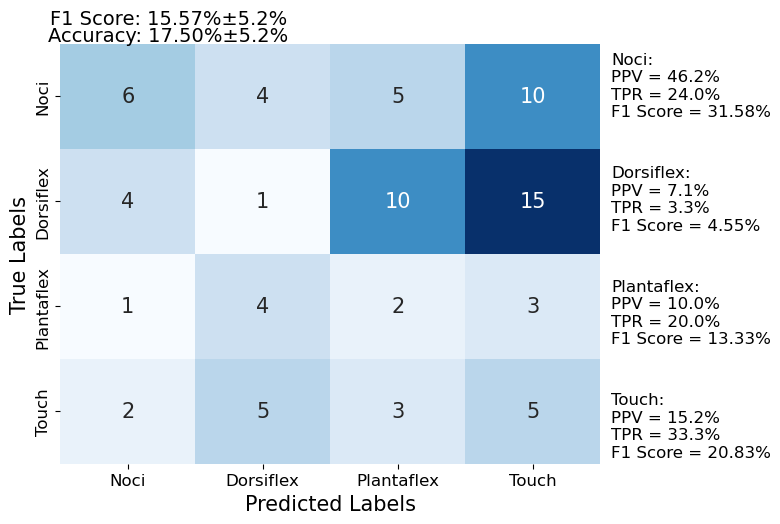

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 1/50ms/EEGNet_4_class_Animal 1_50ms_results.pickle


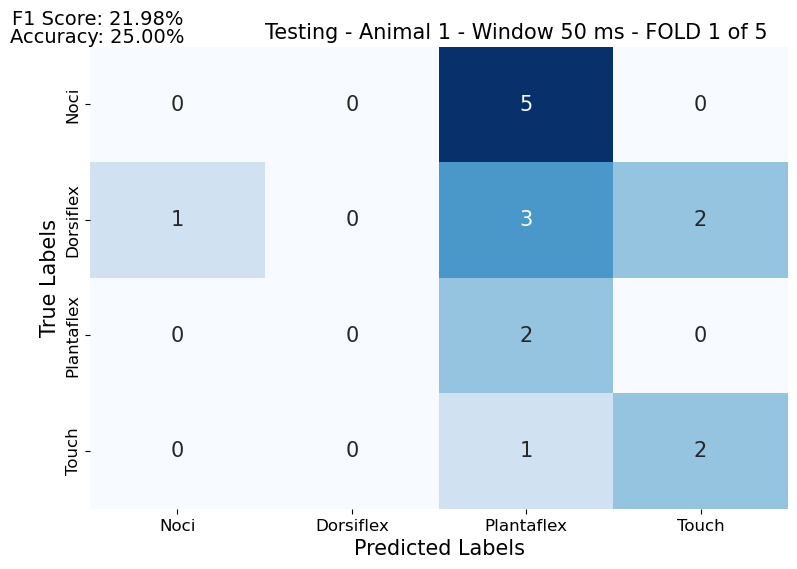

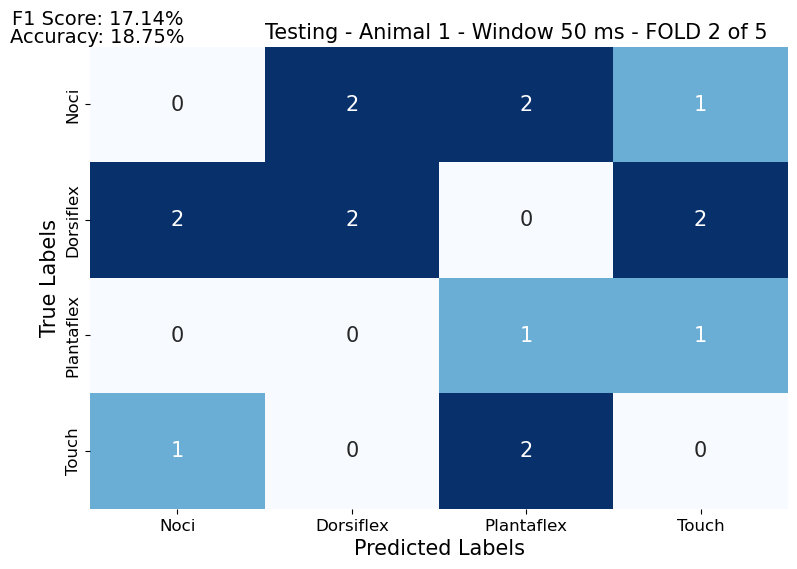

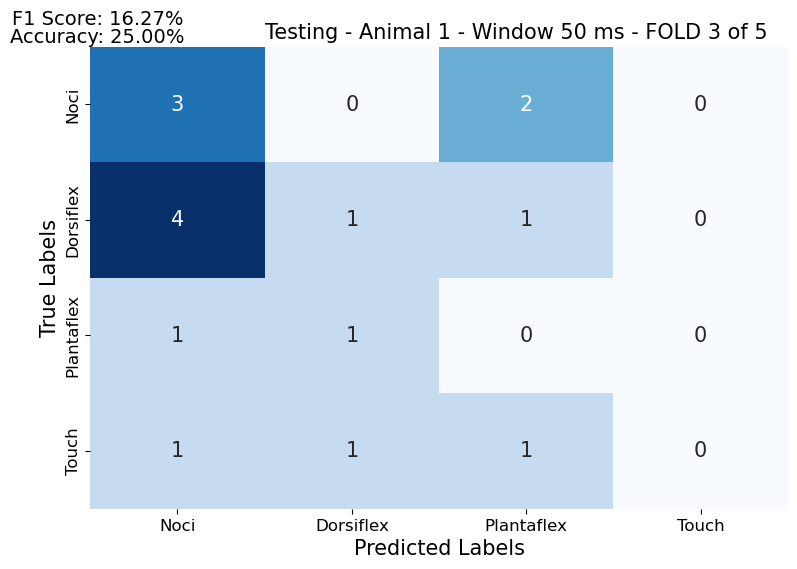

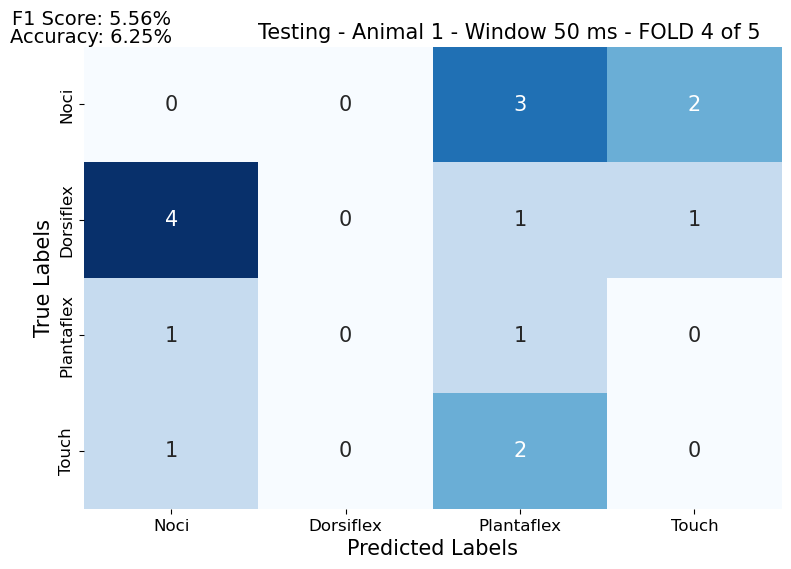

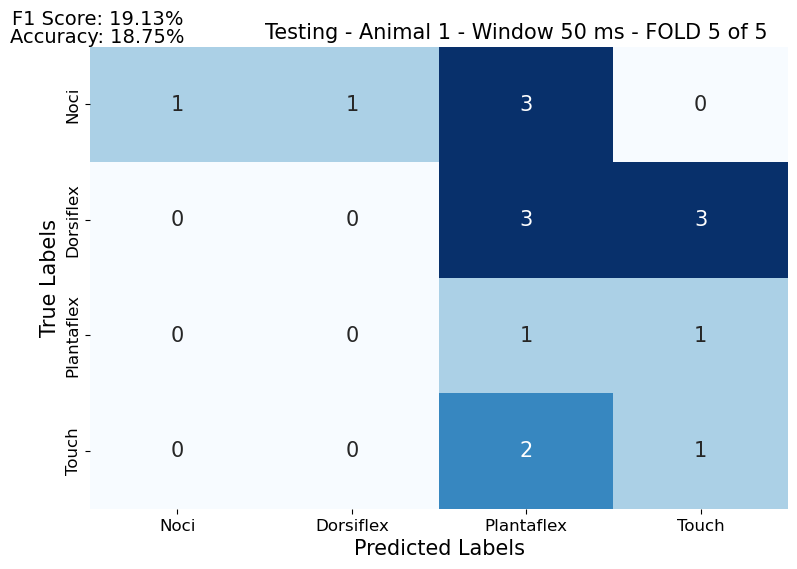

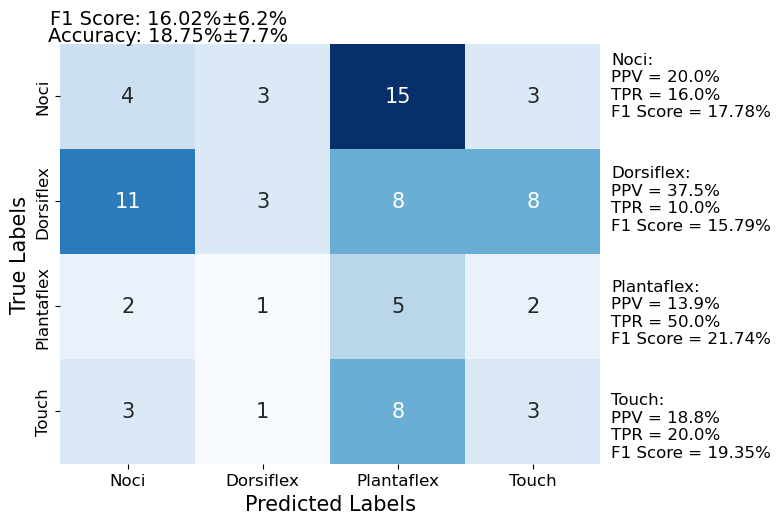

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 2/500ms/EEGNet_4_class_Animal 2_500ms_results.pickle


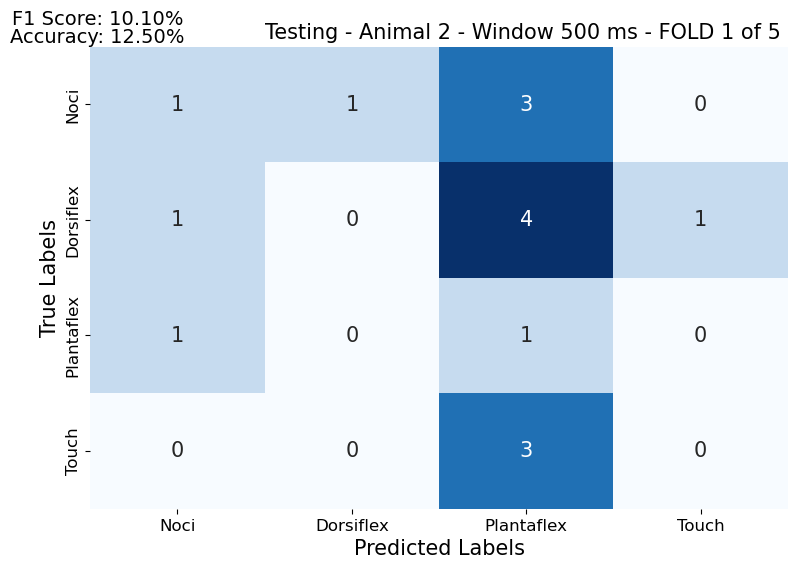

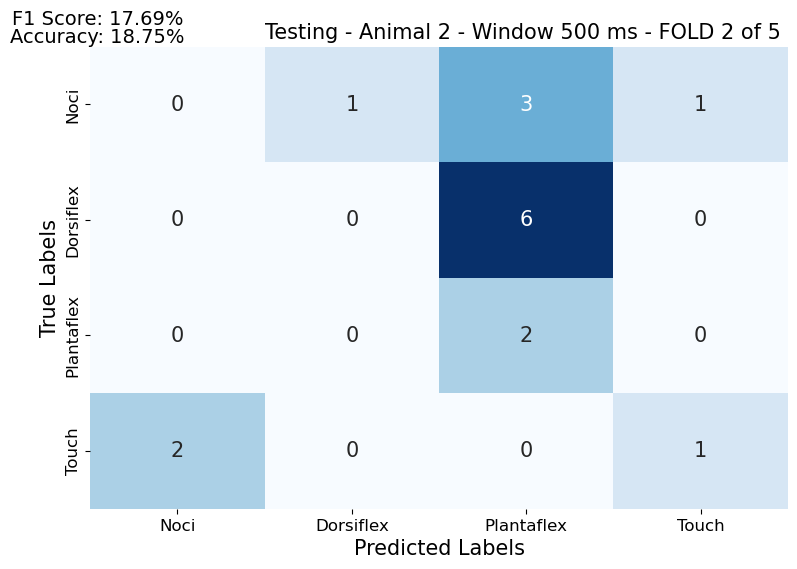

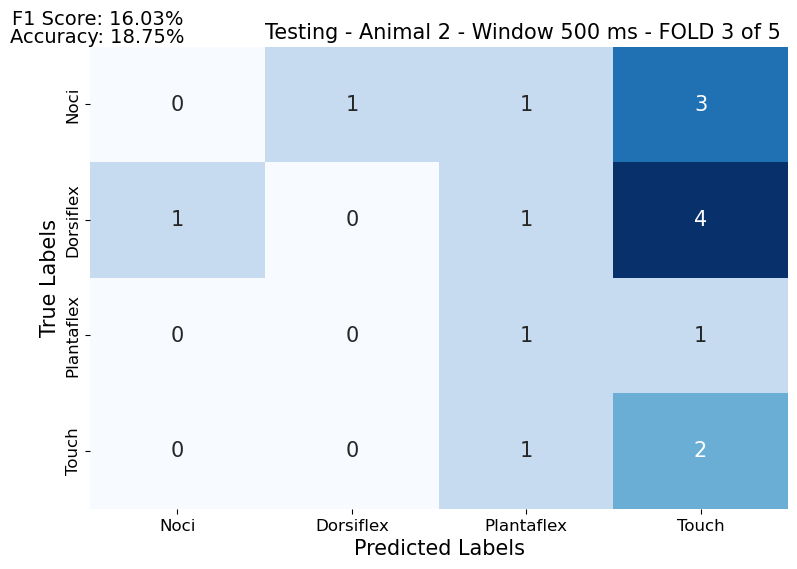

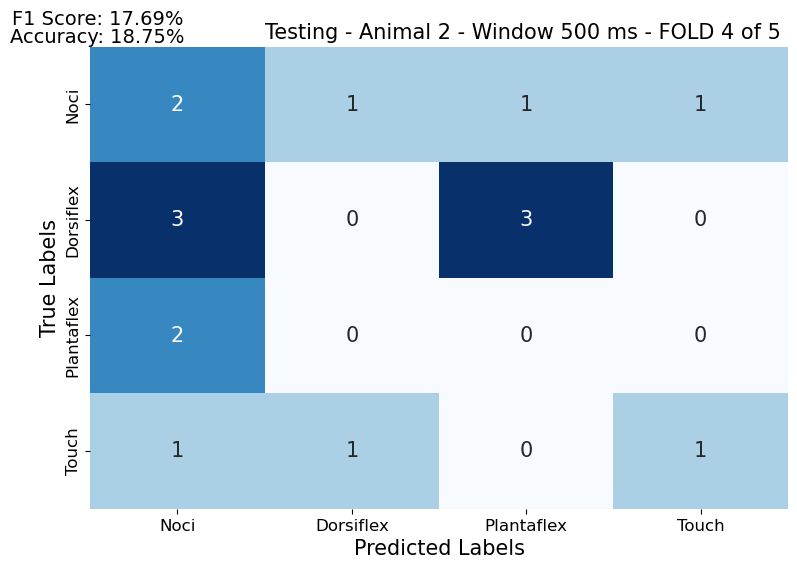

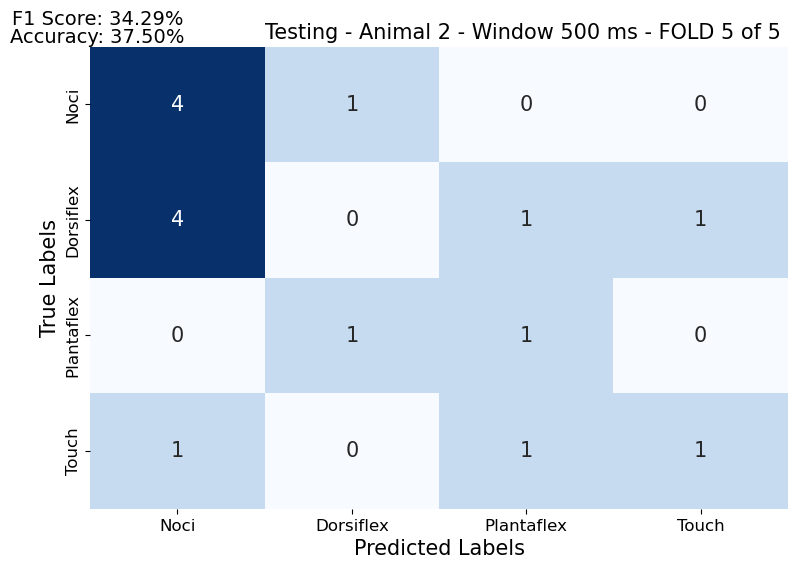

C:\Users\david\DatiTesiRAW\Github\PyPNRelay\toolbox\plots\Plot.py:459: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * (ppv * tpr) / (ppv + tpr)


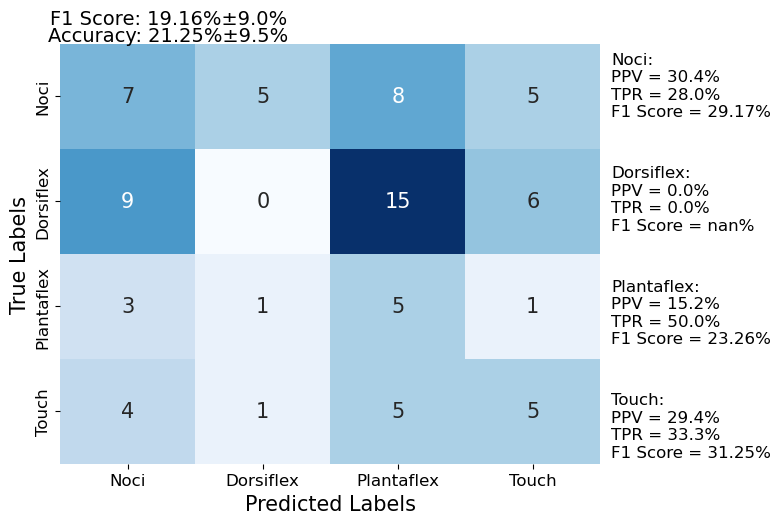

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 2/200ms/EEGNet_4_class_Animal 2_200ms_results.pickle


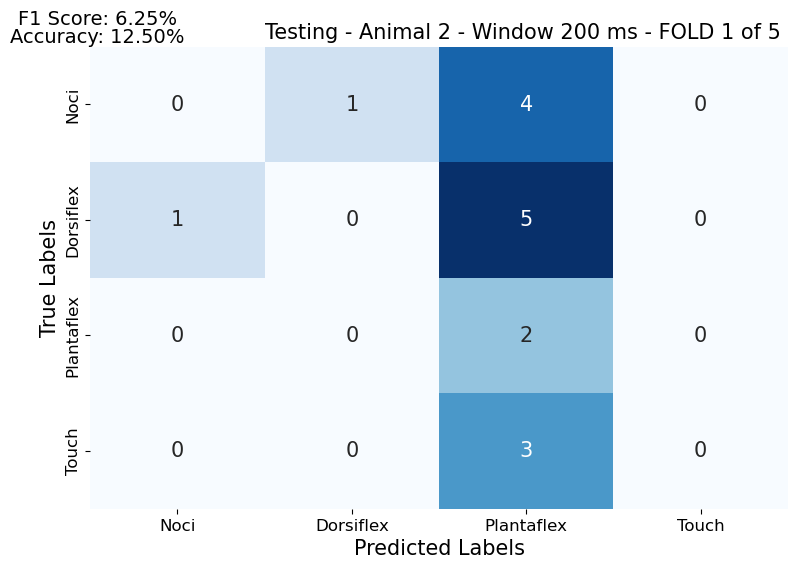

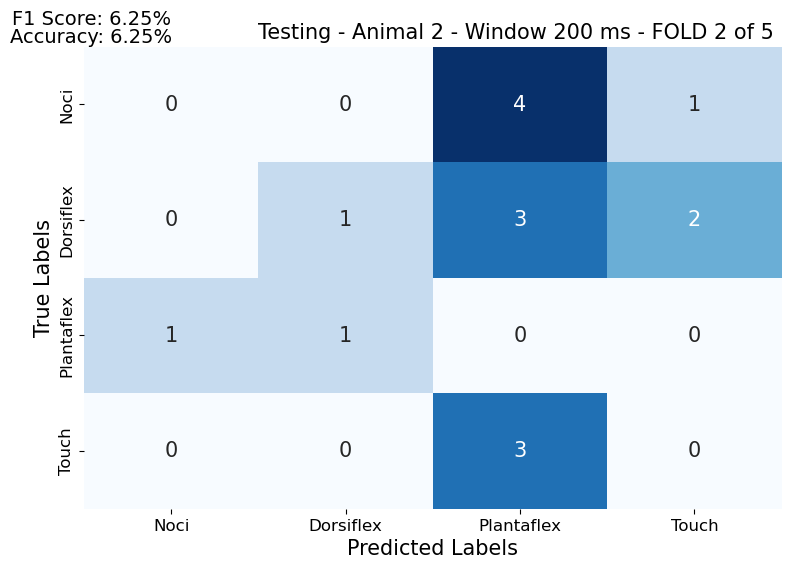

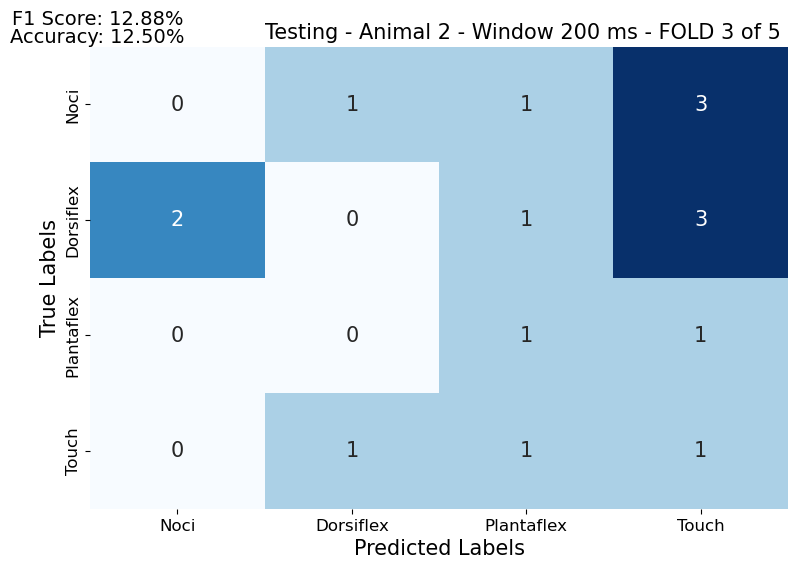

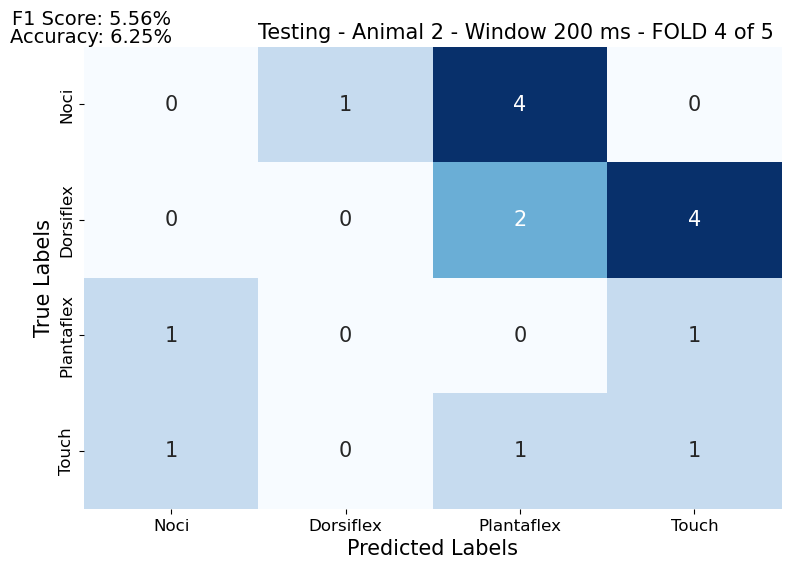

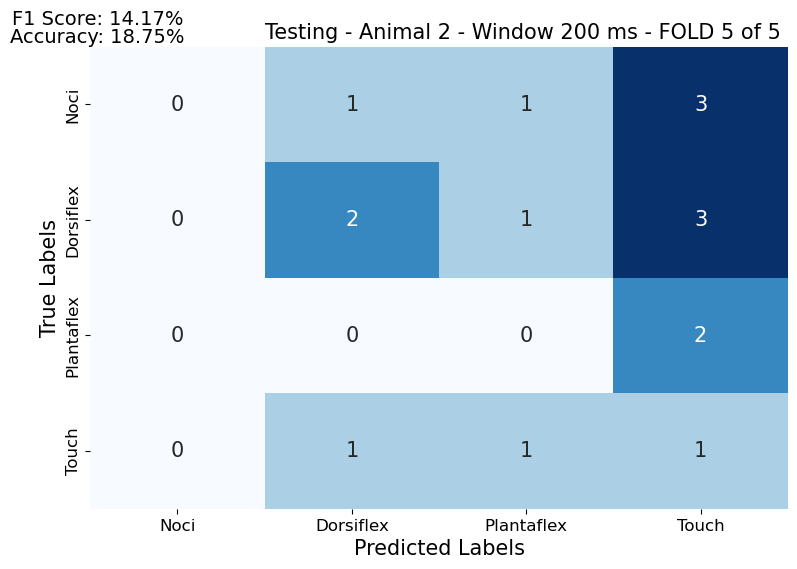

C:\Users\david\DatiTesiRAW\Github\PyPNRelay\toolbox\plots\Plot.py:459: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * (ppv * tpr) / (ppv + tpr)


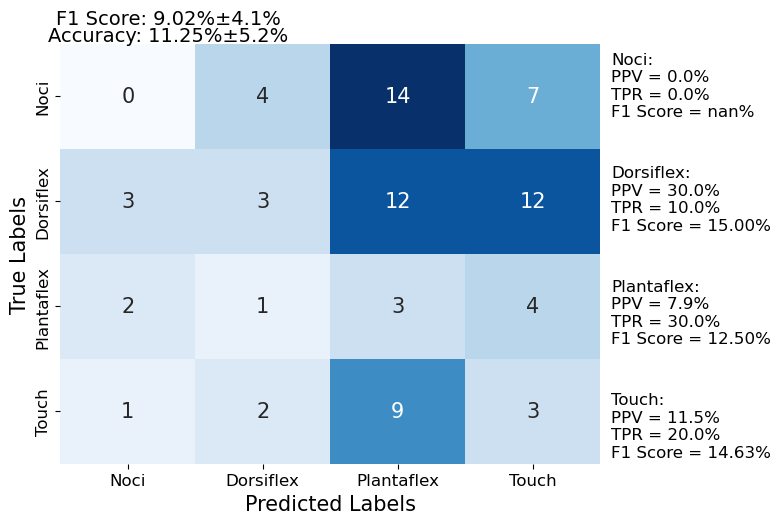

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 2/100ms/EEGNet_4_class_Animal 2_100ms_results.pickle


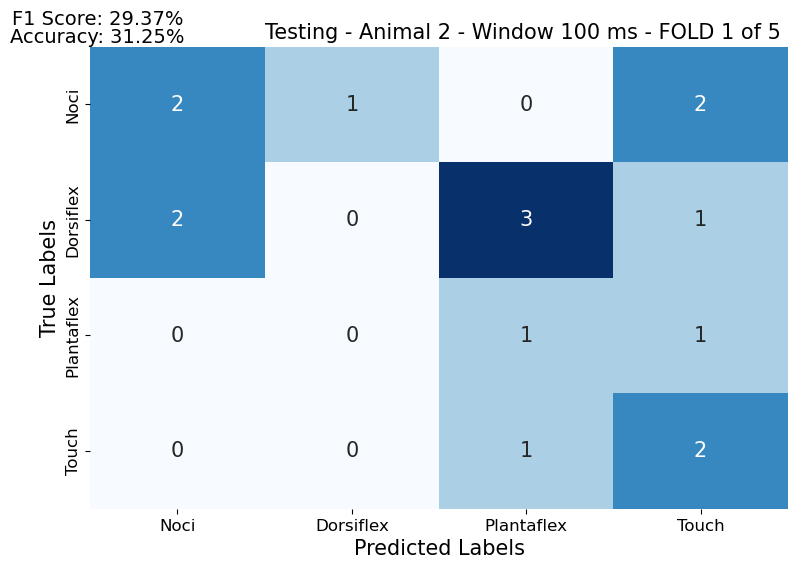

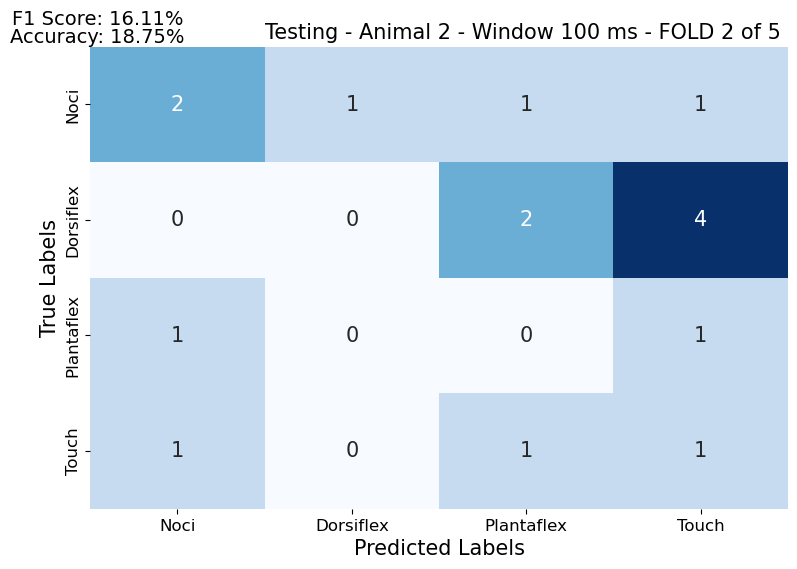

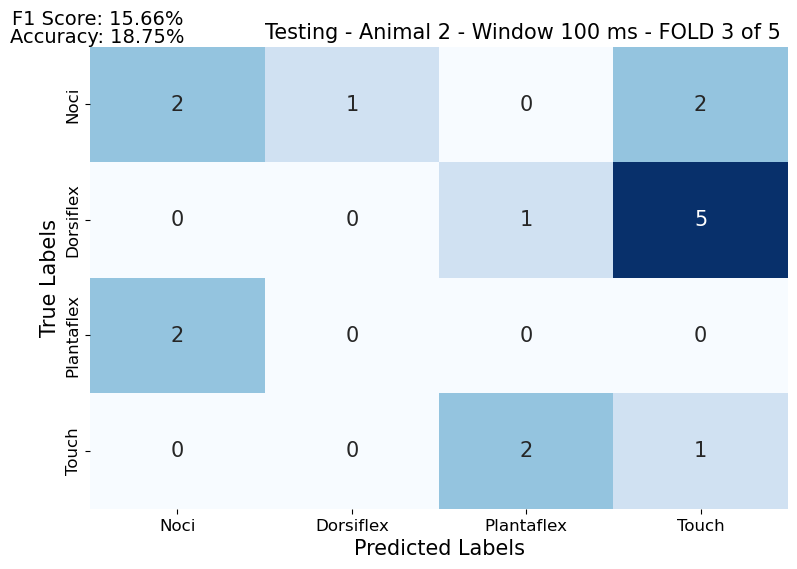

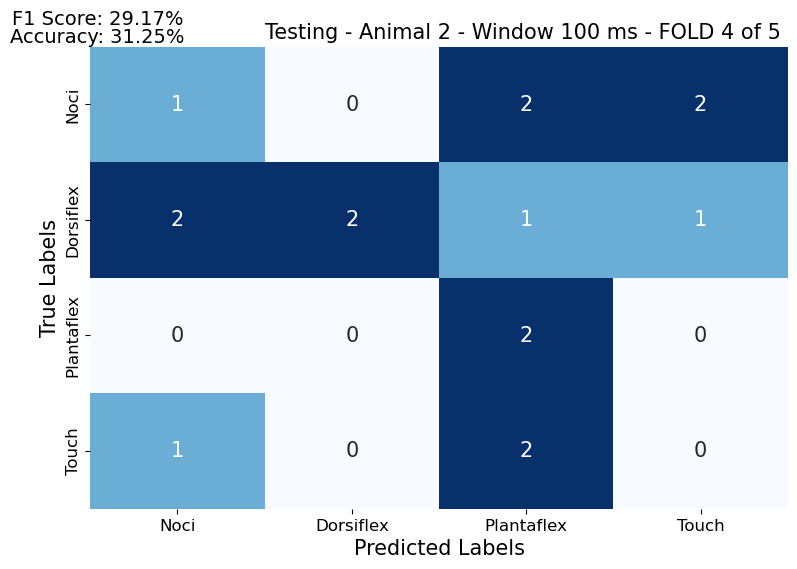

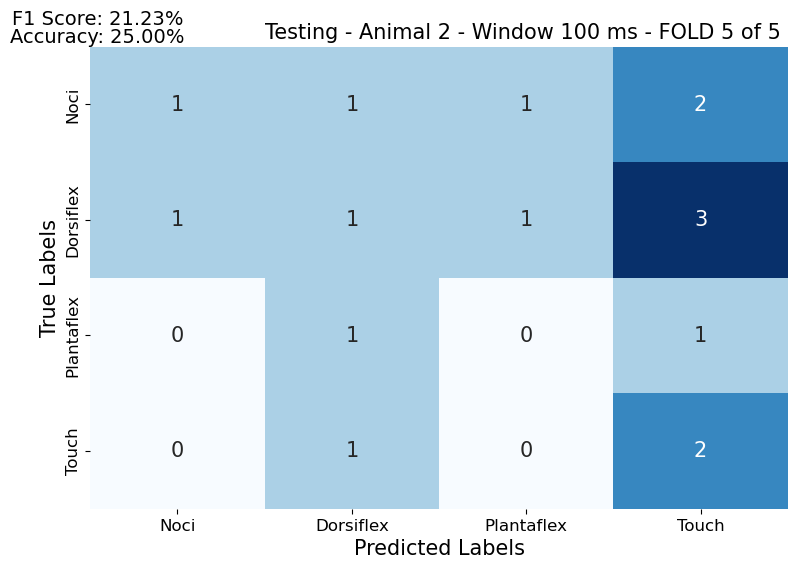

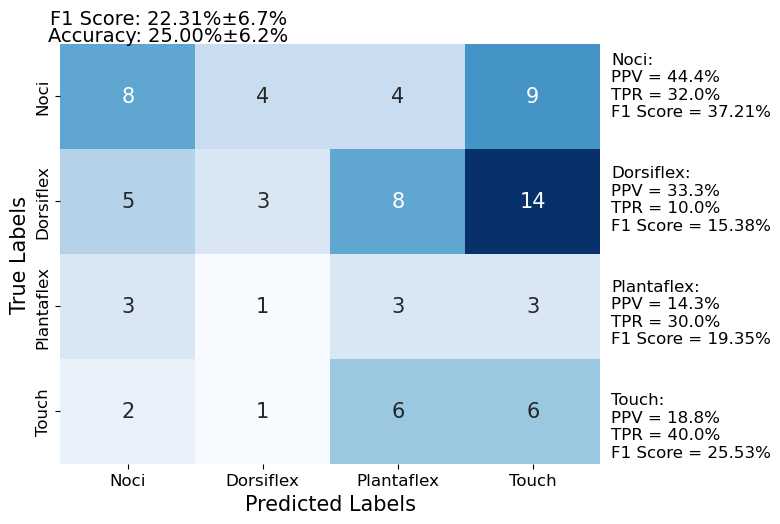

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 2/50ms/EEGNet_4_class_Animal 2_50ms_results.pickle


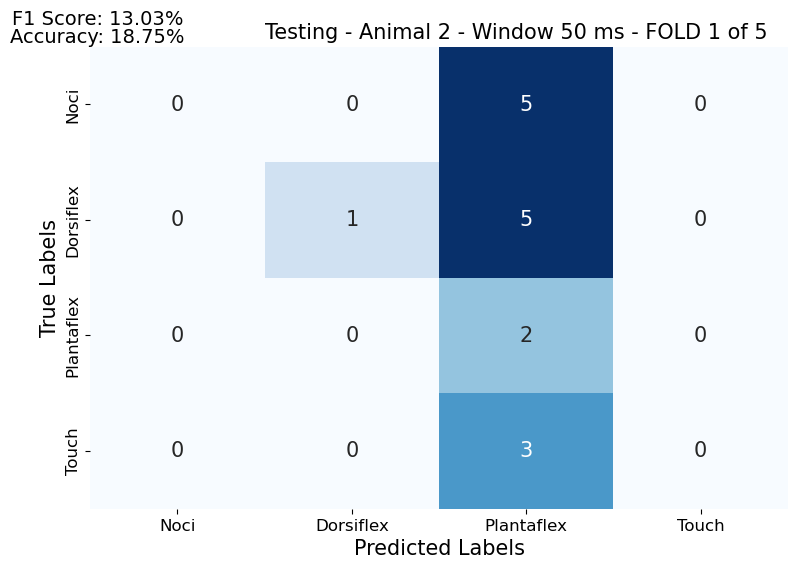

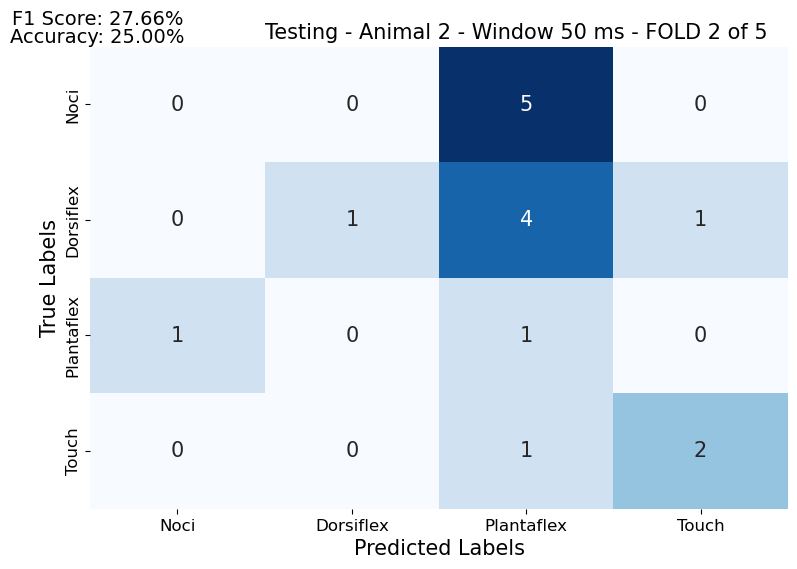

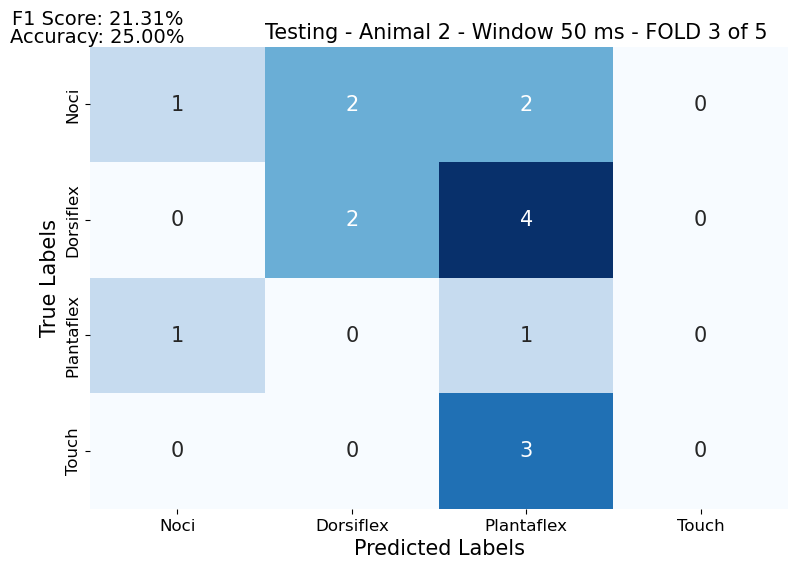

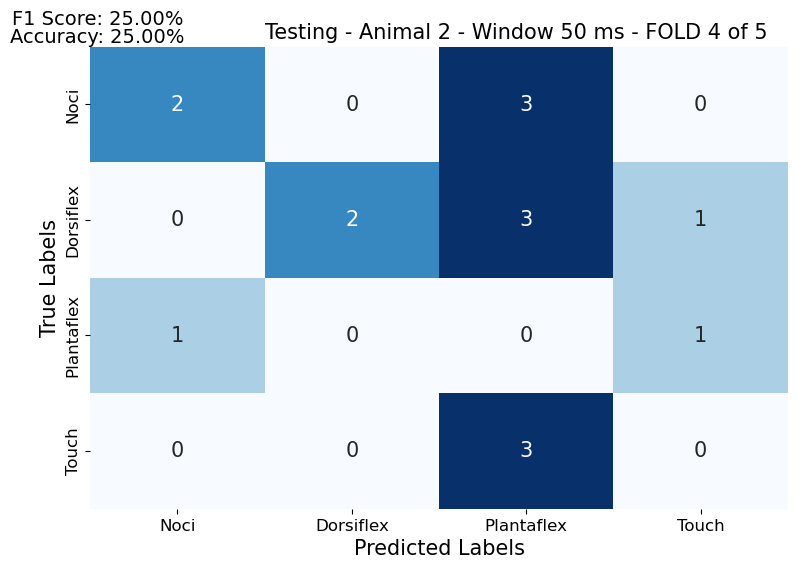

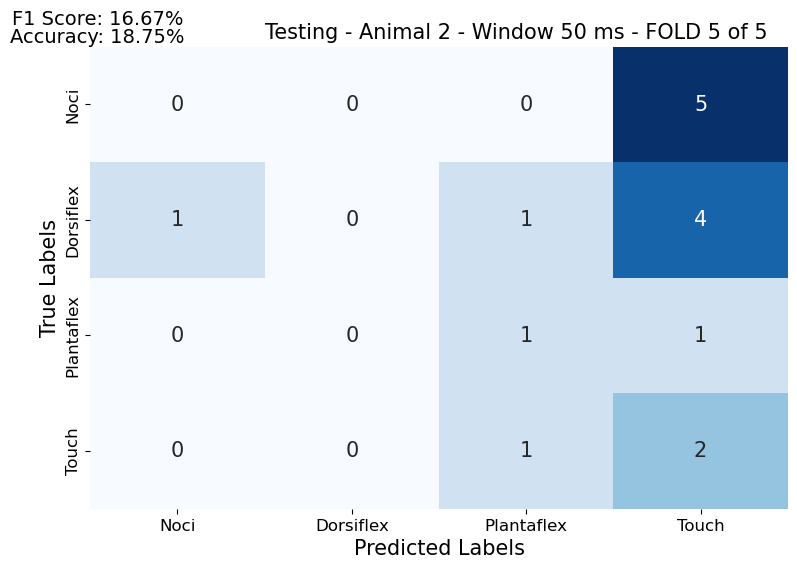

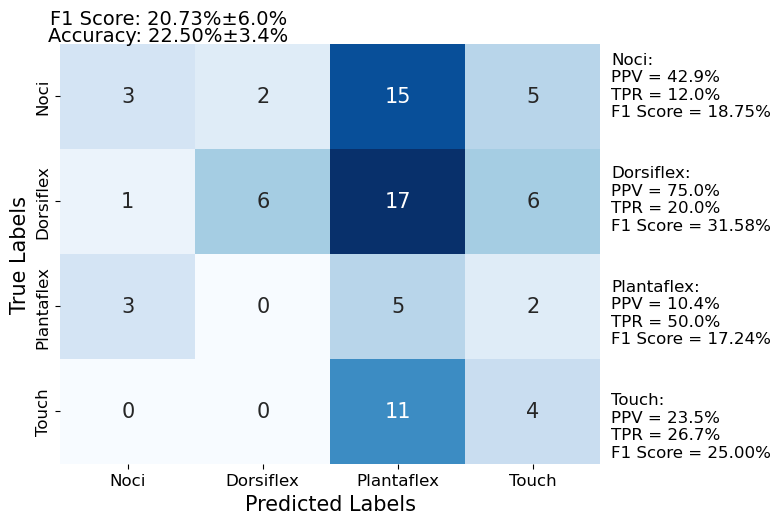

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 3/500ms/EEGNet_4_class_Animal 3_500ms_results.pickle


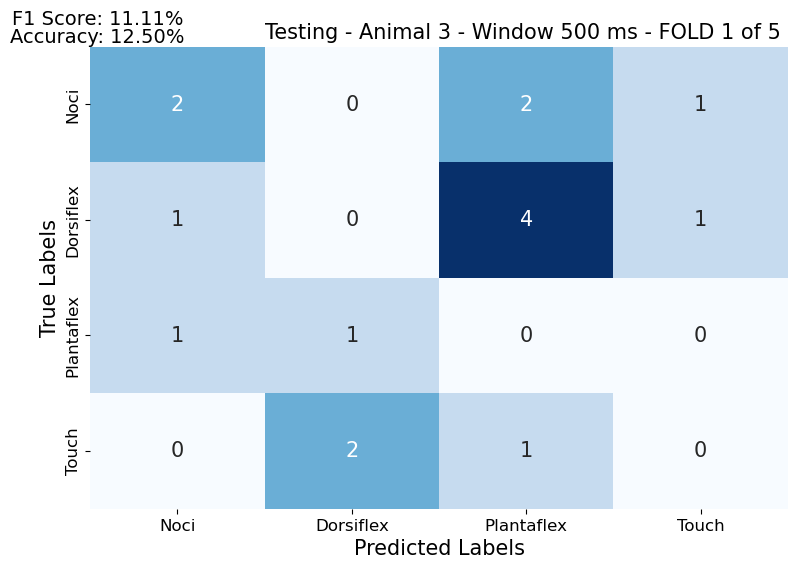

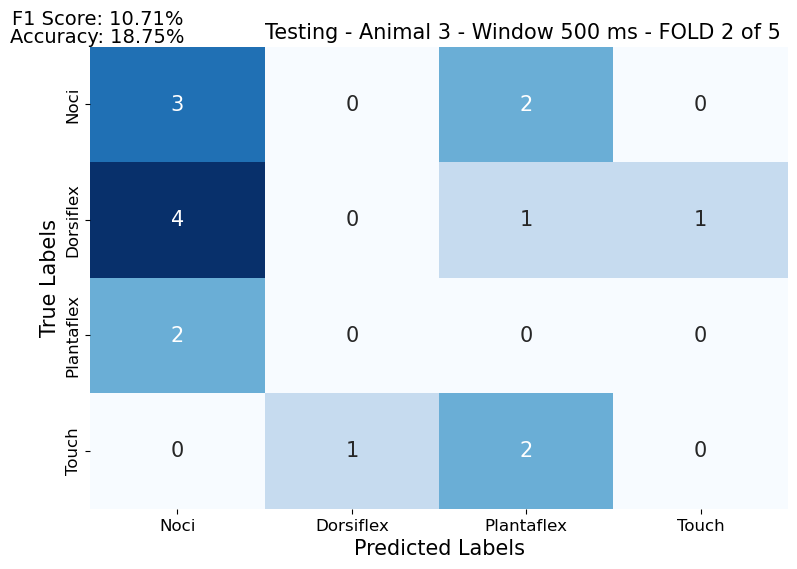

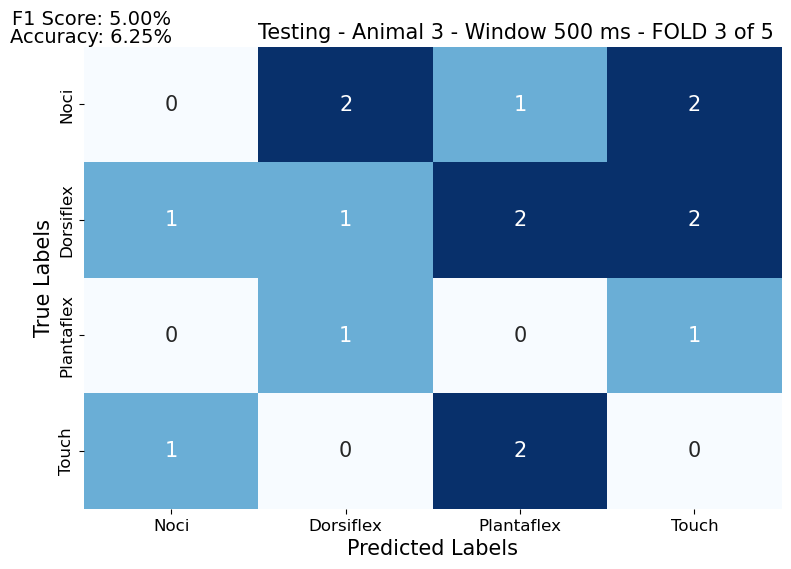

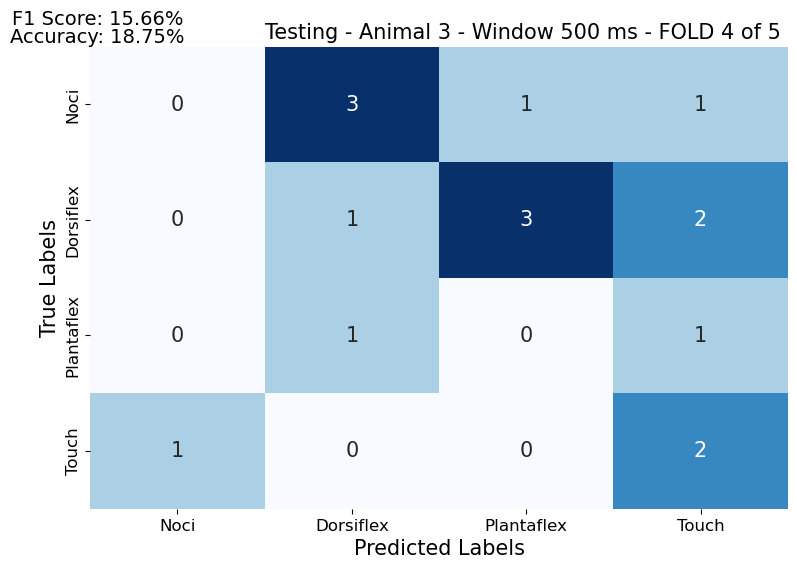

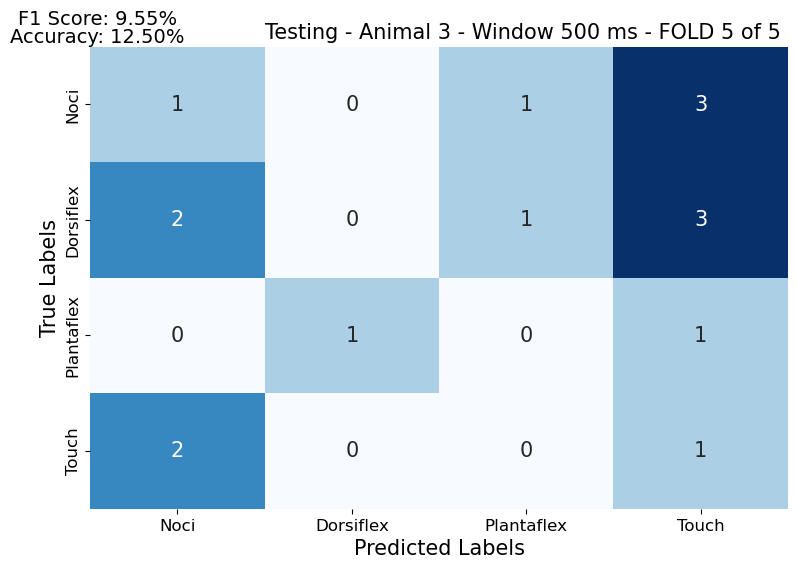

C:\Users\david\DatiTesiRAW\Github\PyPNRelay\toolbox\plots\Plot.py:459: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * (ppv * tpr) / (ppv + tpr)


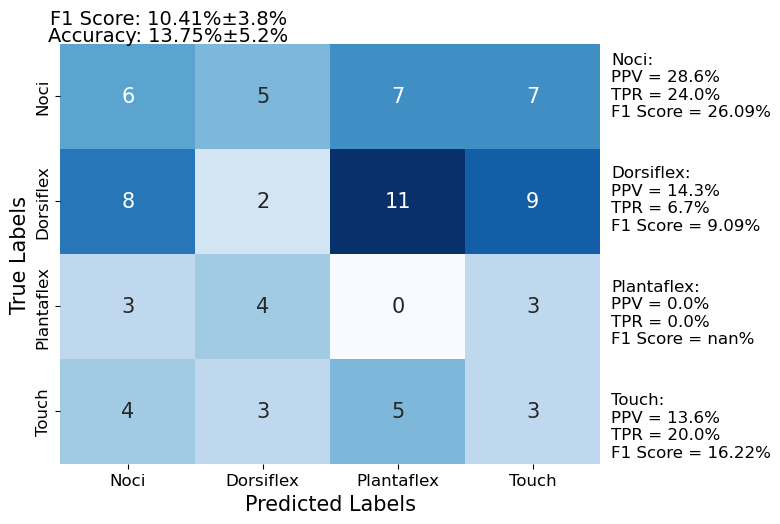

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 3/200ms/EEGNet_4_class_Animal 3_200ms_results.pickle


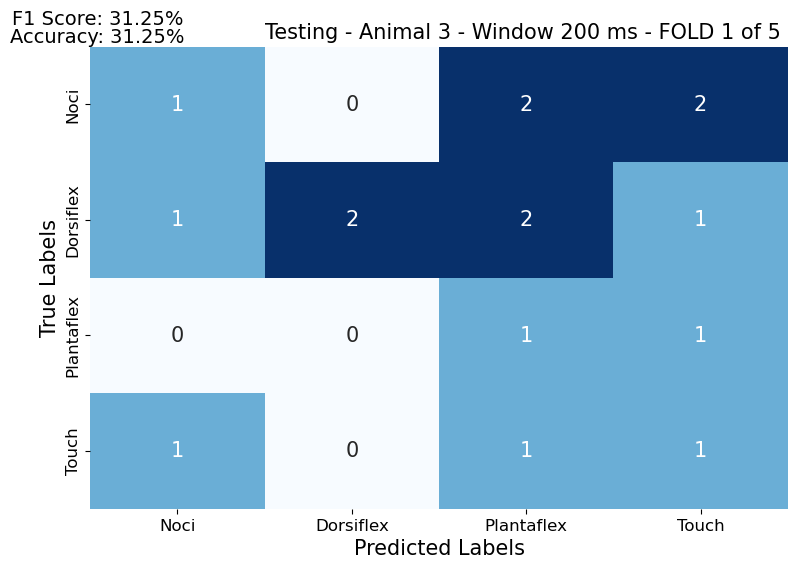

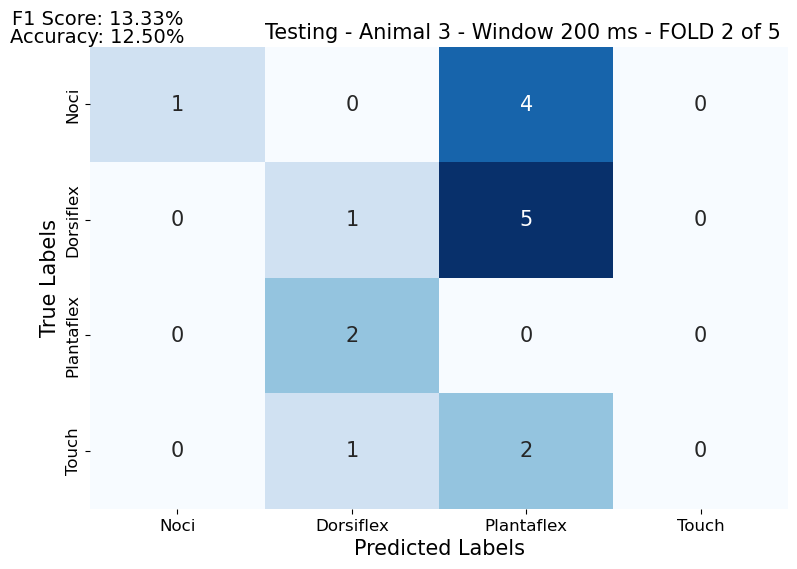

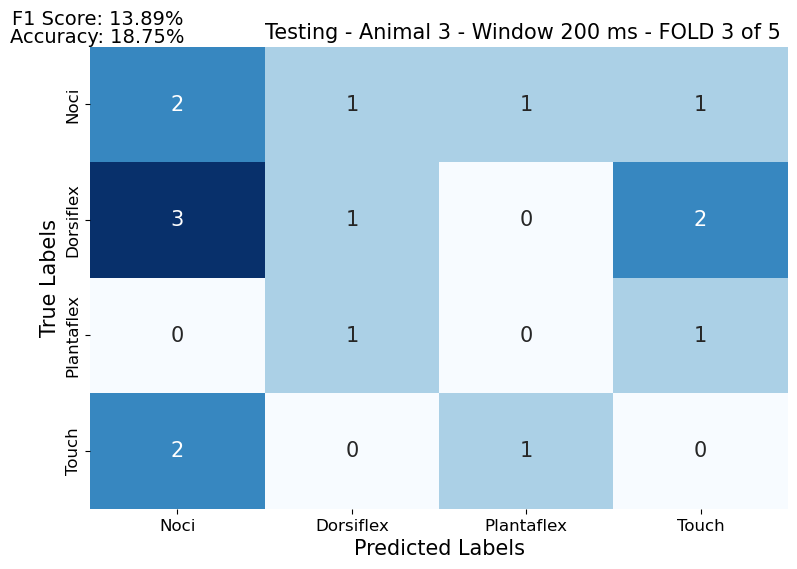

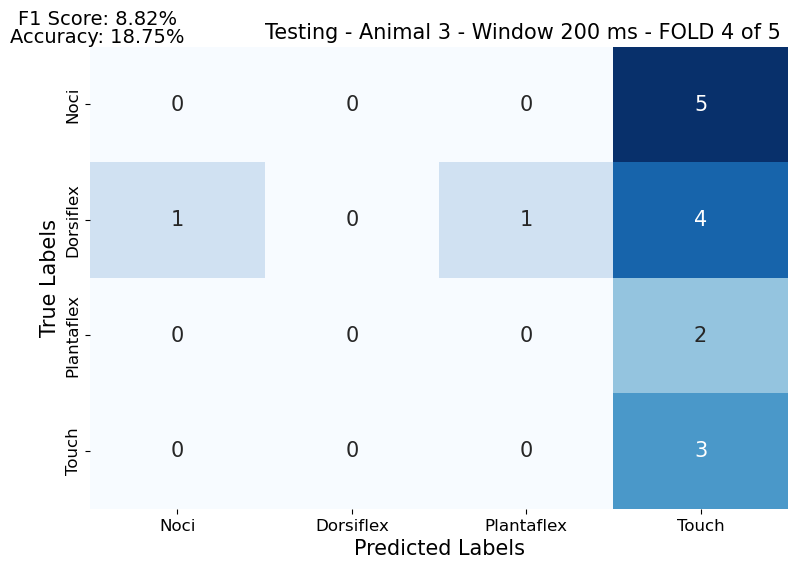

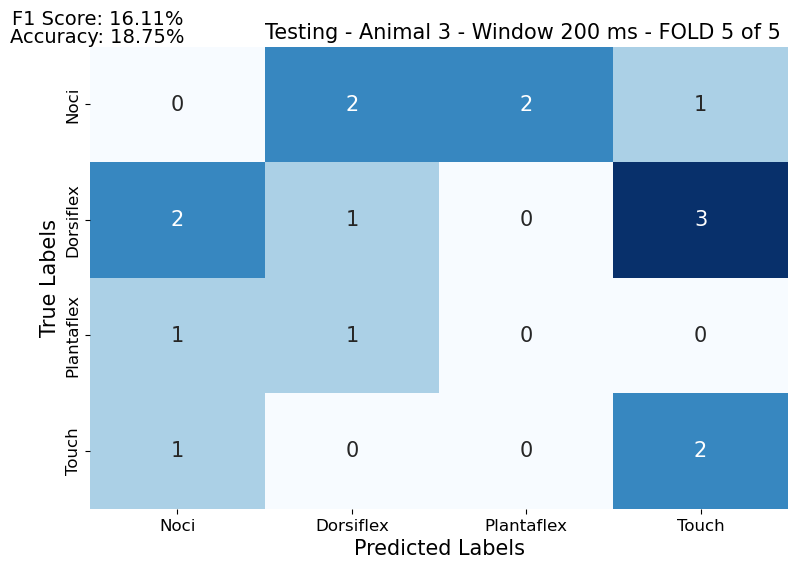

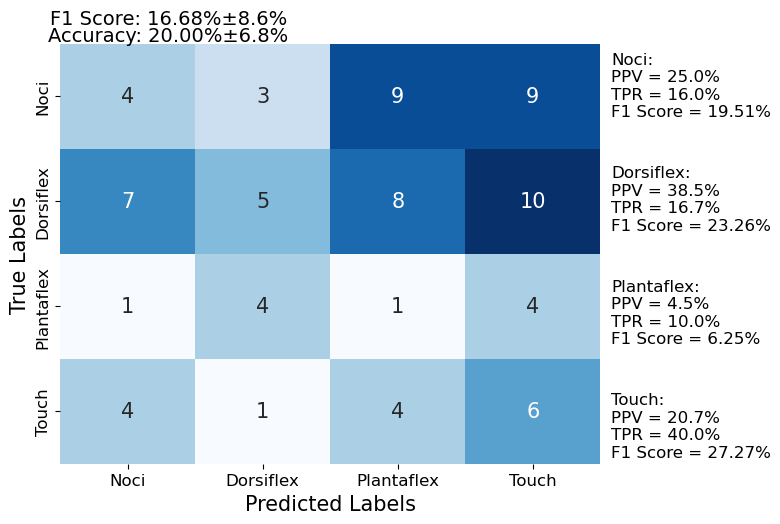

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 3/100ms/EEGNet_4_class_Animal 3_100ms_results.pickle


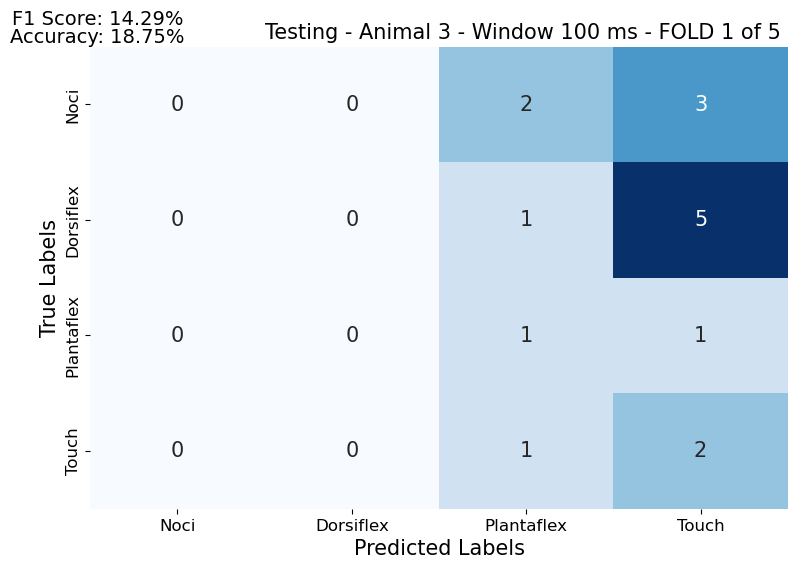

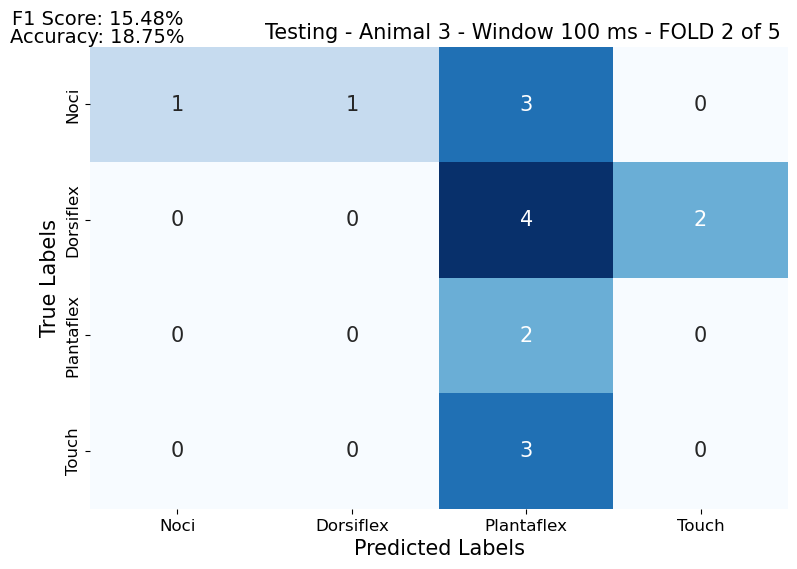

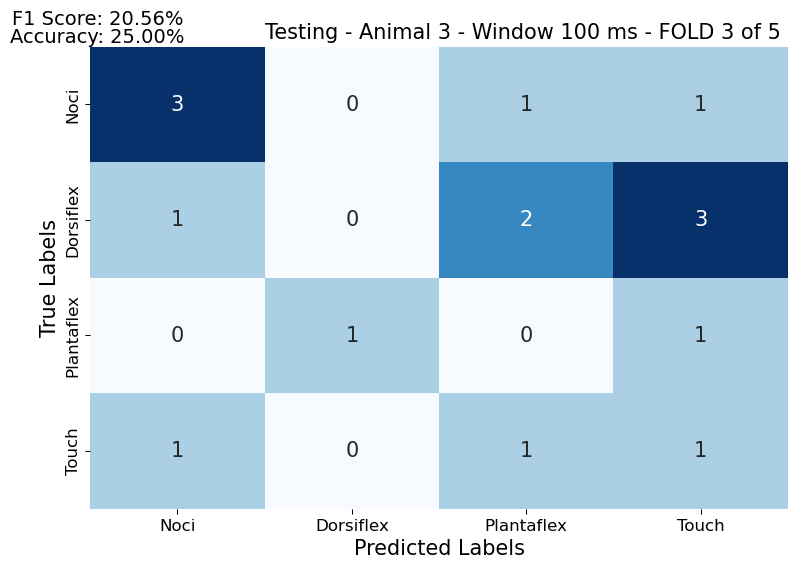

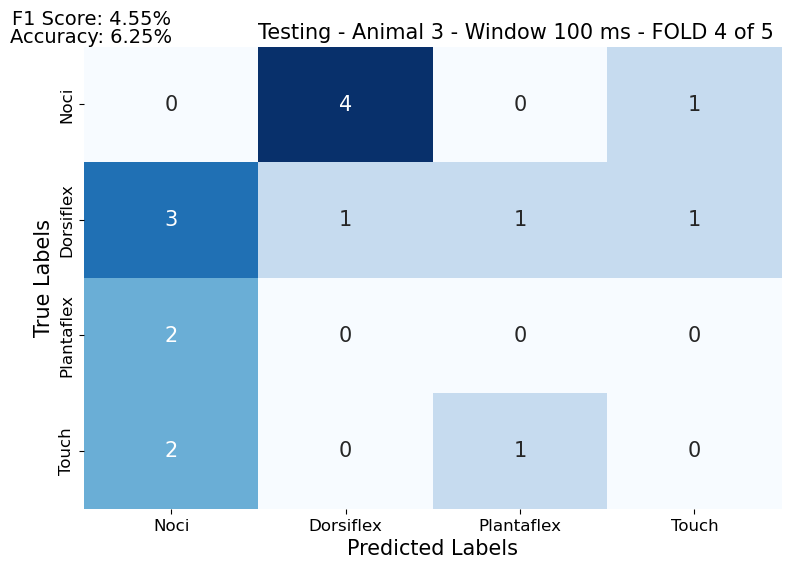

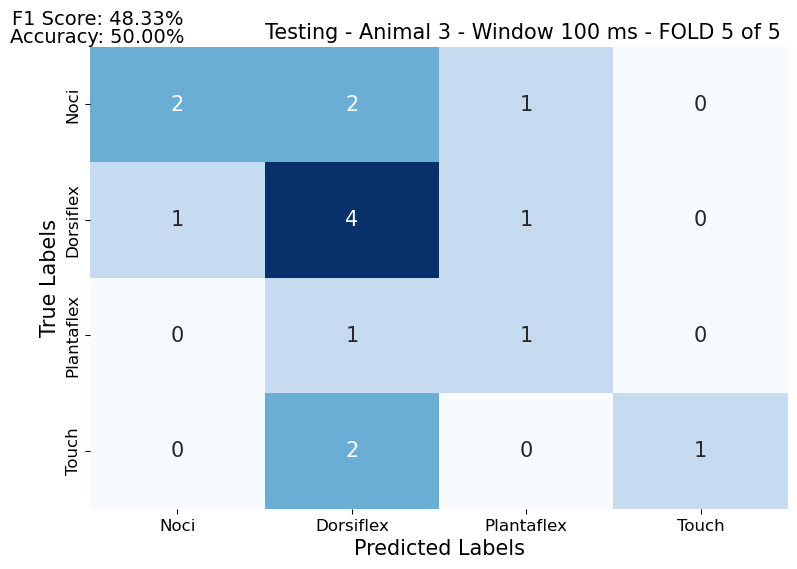

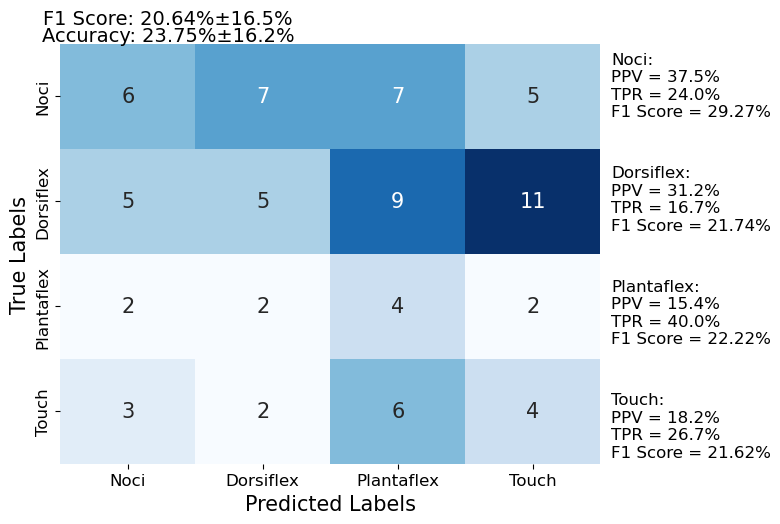

C:\Users\david\DatiTesiRAW\Github\PyPNRelay/results dataset 1/EEGNet/4_class//Animal 3/50ms/EEGNet_4_class_Animal 3_50ms_results.pickle


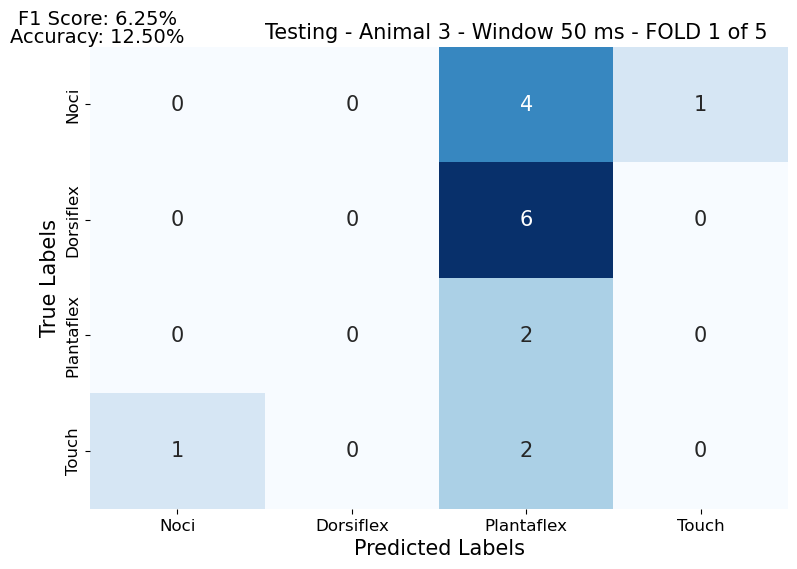

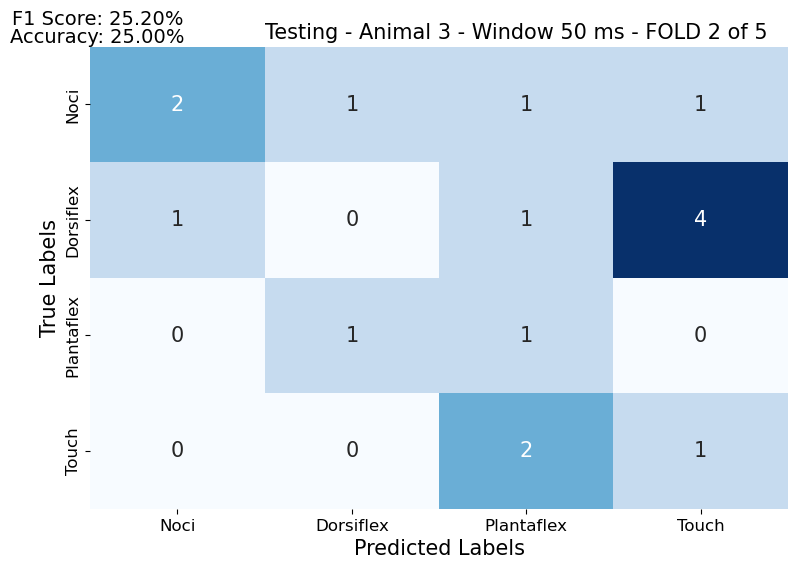

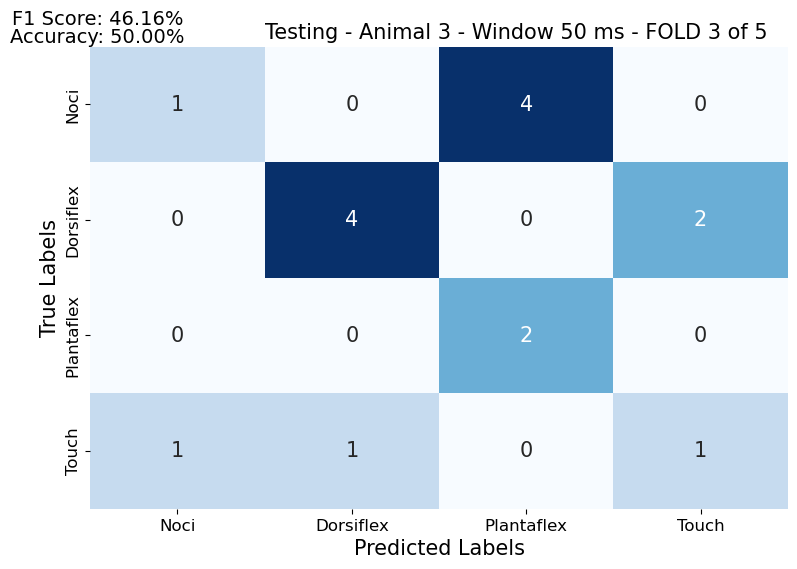

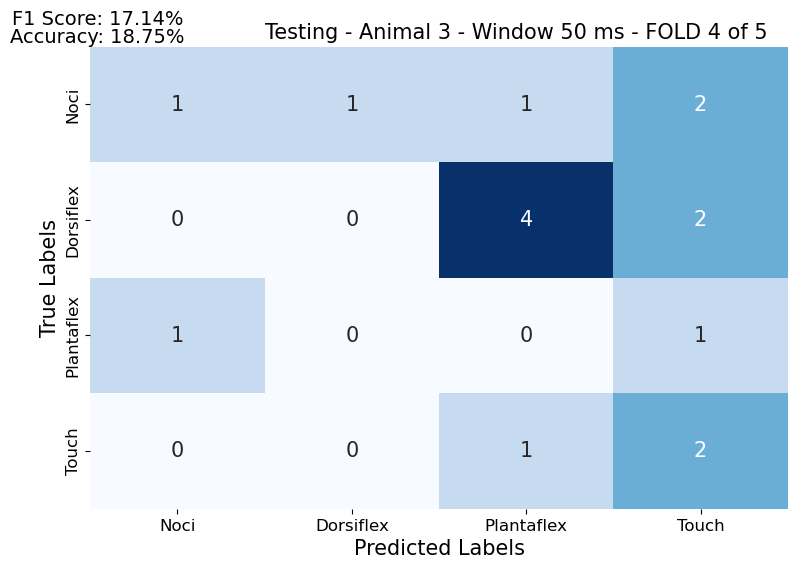

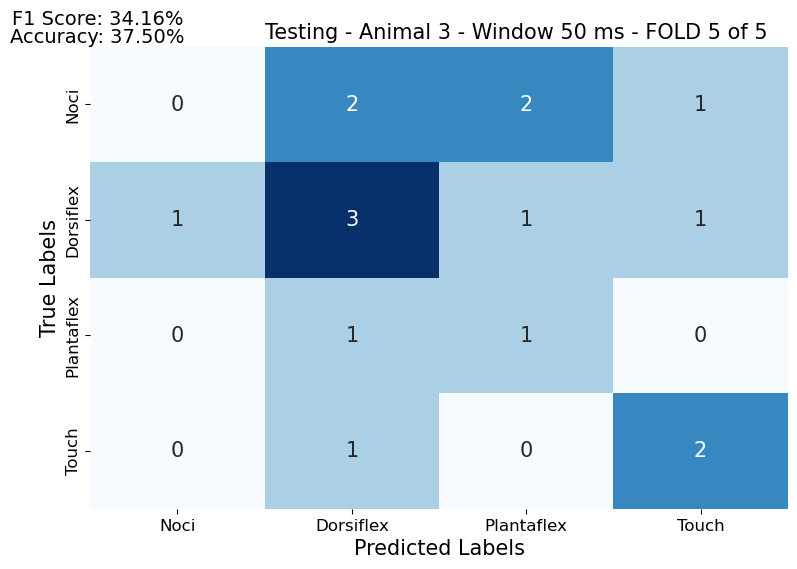

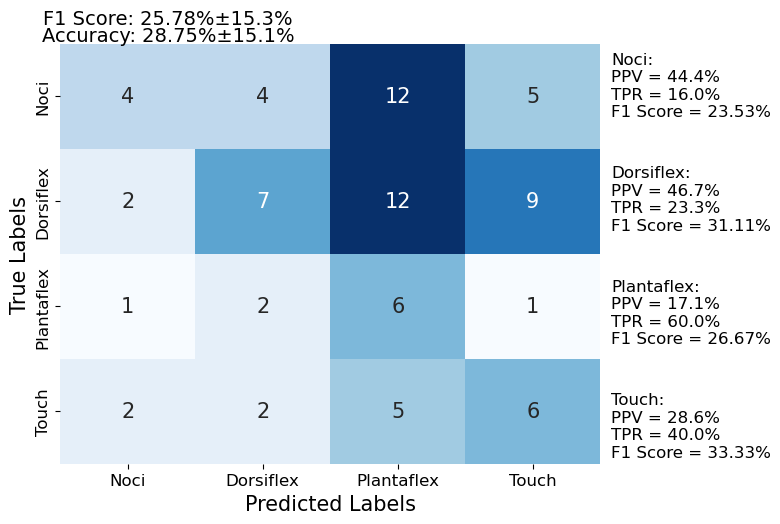

In [5]:
base_folders = []
base_dir = os.getcwd()  # Get current working directory
for classifier in classifiers:
    for animal in animals:
        for window in windows:
            base_folder = f'{base_dir}/results {dataset}/{classifier}/{n_classes}_class/{feature_selection}/'
            CM_plot(base_folder, classifier, animal, window, n_classes)
